In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
import gc
from matplotlib import cm
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from scipy import linalg
from astropy.cosmology import Planck18

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5
G_lo = 20.0

In [4]:
nthreads = 18

In [5]:
# cosmology 1
h=0.6844
Omega_m = 0.302

# cosmology 2
Omega_m_quaia = 0.343
h_quaia = 0.674

In [6]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [7]:
H0 = h*100 * u.km/u.s/u.Mpc
rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

H0_quaia = h_quaia*100 * u.km/u.s/u.Mpc
rbins_Mpc_quaia = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_quaia))

In [8]:
color1 = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, 2))[::-1]
color2 = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, 2))[::-1]

In [9]:
color3 = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, 2))[::-1]

In [10]:
# Create the bins array
rpmin = 0.15 # 0.5 # 0.1 # start higher
rpmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rpbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [11]:
pimax = 80 # 40 # 5000.0 # 40.0

In [12]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [13]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [14]:
Omega_c = 0.2513
Omega_b = 0.048
Omega_m_planck = Omega_c+Omega_b
cosmo = ccl.Cosmology(Omega_c=Omega_m*Omega_c/Omega_m_planck, Omega_b=Omega_m*Omega_b/Omega_m_planck,
                          h=h, n_s=0.95, sigma8=0.8)
cosmo_quaia = ccl.Cosmology(Omega_c=Omega_m_quaia*Omega_c/Omega_m_planck, Omega_b=Omega_m_quaia*Omega_b/Omega_m_planck,
                          h=h_quaia, n_s=0.95, sigma8=0.766)

In [15]:
Omega_m_planck20 = 0.315

In [16]:
# actual planck 2018 params are slightly different should i use those?
cosmo_planck20 = ccl.Cosmology(Omega_c=0.265, Omega_b=0.049, h=0.674, n_s=0.95, sigma8=0.8)

In [17]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [18]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [19]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
grey = plt.get_cmap('Greys')((0.333+0.999)/2)
colors = [orange, green]

In [20]:
labels = ['Planck18', 'Planck20', 'Quaia23']

In [21]:
h = 0.6774
Delta = 200
delta_c = 1.686

In [22]:
cosmo_default = ccl.Cosmology(Omega_b=0.0486, Omega_c=0.2589, h=h, n_s=0.9667, sigma8=0.8159)
hmf = ccl.halos.MassFuncTinker10()

In [23]:
NSIDE = 64
# fn_selhi = f"../data/maps/selection_function_NSIDE64_G20.5.fits"
# selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [24]:
M_max = 15

## Define functions

In [25]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [26]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [27]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_default):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [28]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_default, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_default, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [29]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [30]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [31]:
def M(bins, n_m, a = 1, cosmo = cosmo_default, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        # dm = np.diff(bins) 
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [32]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [33]:
# def n_DM(bins, cosmo, a, M_min, hmf = hmf):
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    # dn_dm[quaia.recenter(bins)>=M_min] = 0
    
    # return np.trapz(dn_dm[quaia.recenter(bins)>=M_min], quaia.recenter(bins)[quaia.recenter(bins)>=M_min])
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [34]:
# bins = np.logspace(9, 16.9, 50)
# bins = np.logspace(9, 16.8, 79)
bins = np.logspace(9, M_max, 79)
M_min = 12.8

In [35]:
M_min_array = [12.86, 12.74, 12.79, 12.82]

In [36]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/2409304926.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i])
/tmp/ipykernel_38900/2409304926.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


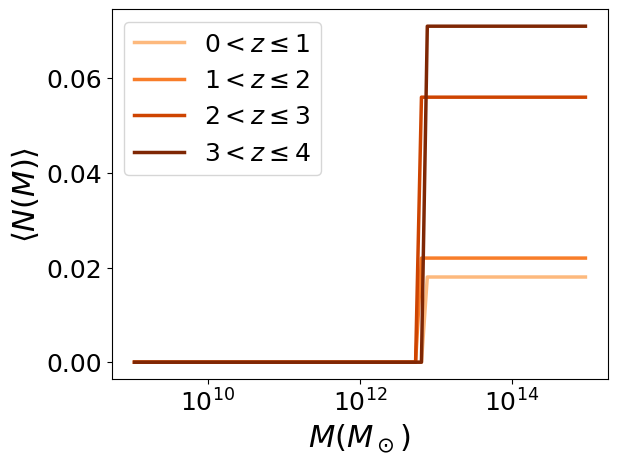

In [37]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i])

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

### Now vary $M_{min}$

In [38]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.zeros(np.shape(quaia.recenter(bins)))
        n_m[quaia.recenter(bins)>=bins[j]]=fduty[i]
        n_m_array_2D[i].append(n_m)

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/4166141031.py:11: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(bins), n_m_array_2D[i][j*k], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i],
/tmp/ipykernel_38900/4166141031.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%$'.format(i, i+1, fduty[i]*100))
/tmp/ipykernel_38900/4166141031.py:19: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel('$M (M_\odot)$')


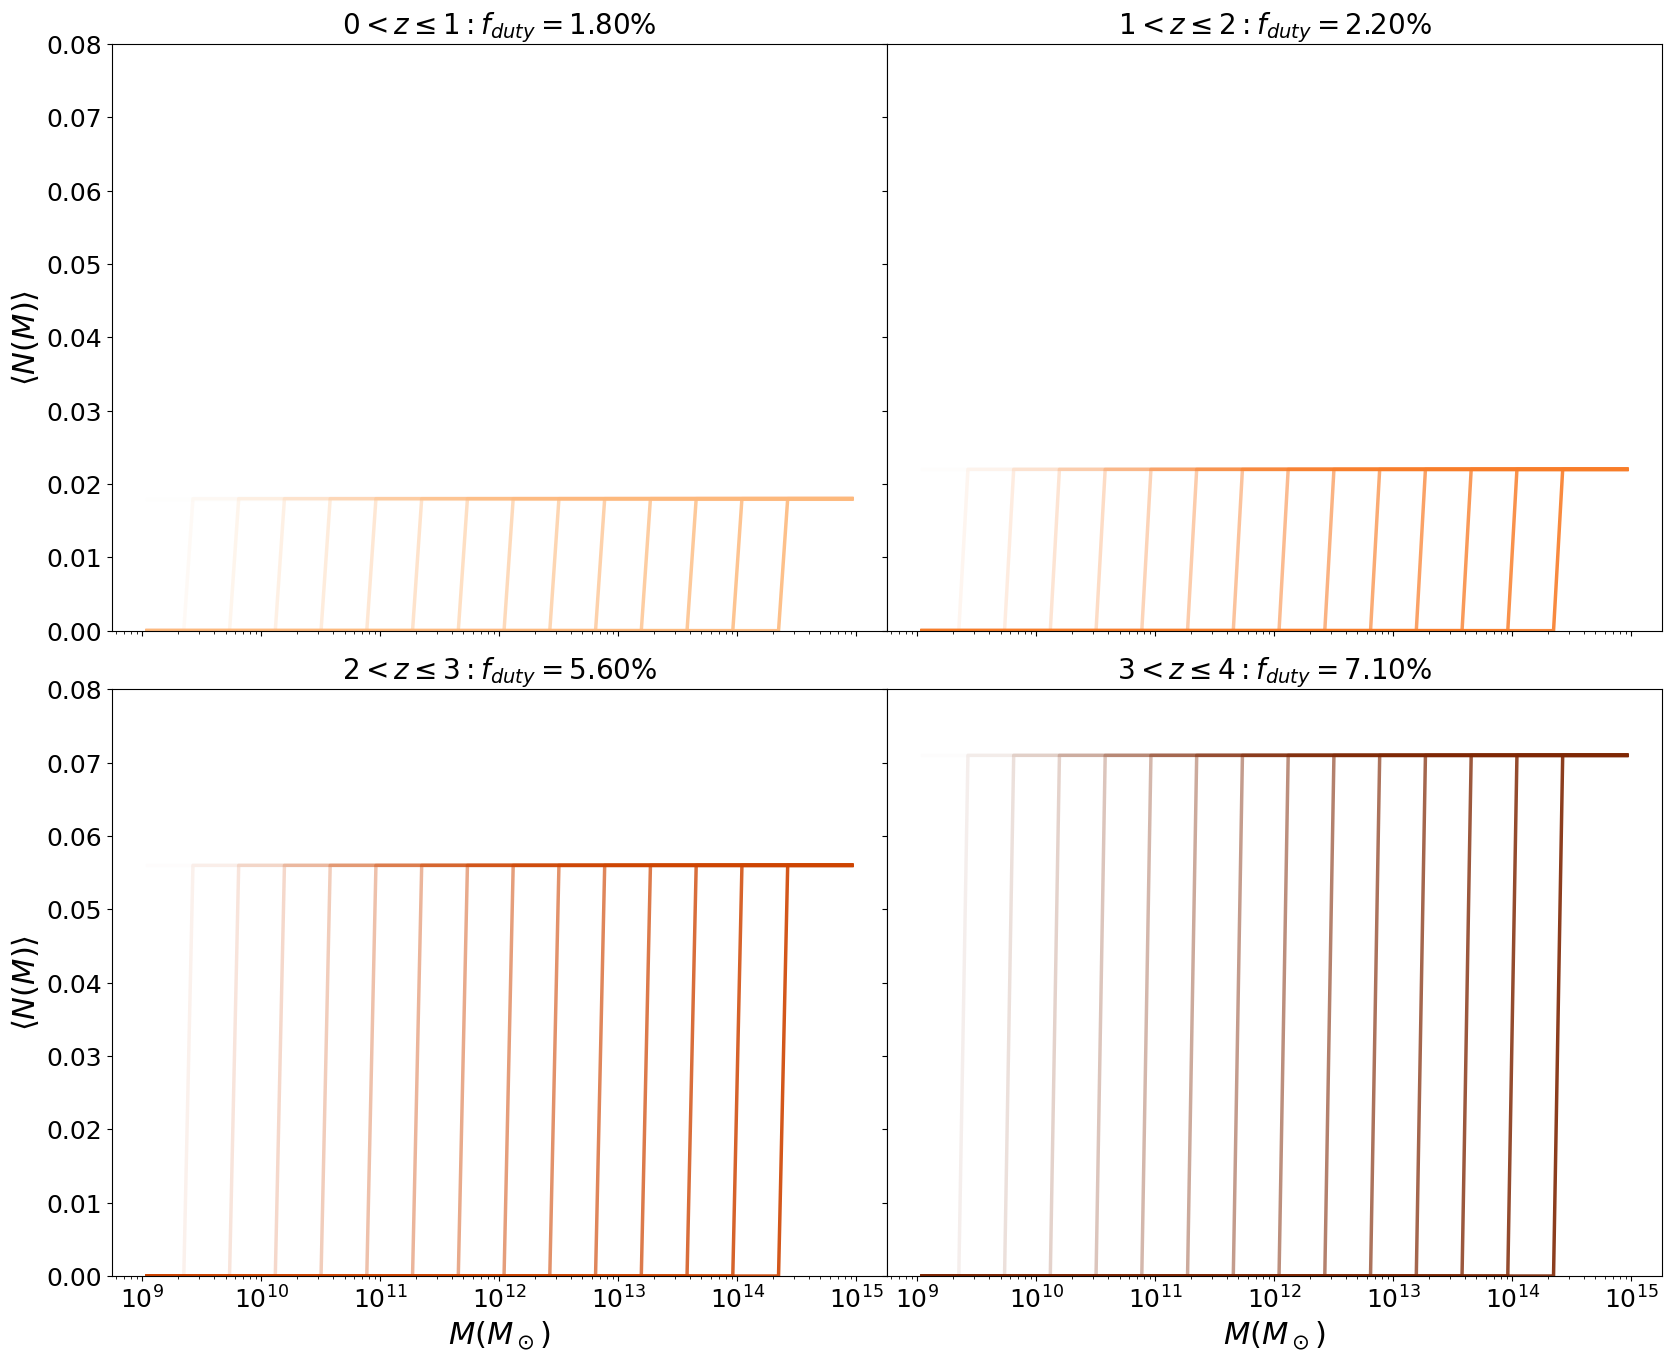

In [39]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
k = 5

for i in z_array:

    ax1 = fig.add_subplot(gs[i])

    for j in range(int(len(bins)/k)):
        
        ax1.plot(quaia.recenter(bins), n_m_array_2D[i][j*k], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i], 
                 alpha = (j*k+1)/len(bins))

    ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%$'.format(i, i+1, fduty[i]*100))
    ax1.set_xscale('log')
    ax1.set_ylim(0, 0.08)

    if i>1:
        ax1.set_xlabel('$M (M_\odot)$')
    else:
        ax1.set_xticklabels([])
    if i%2 == 0:
        ax1.set_ylabel(r'$\langle N(M) \rangle$')
    else:
        ax1.set_yticklabels([])

plt.show()

### And vary $f_{duty}$

In [40]:
fduty_array = np.logspace(-5,0, 51) #-4
n_m_array_3D = []
for i in z_array:

    n_m_array_3D.append([])
    
    for j in range(len(bins)):
        
        n_m_array_3D[i].append([])
        
        for k in range(len(fduty_array)):
        
            n_m=np.zeros(np.shape(quaia.recenter(bins)))
            n_m[quaia.recenter(bins)>=bins[j]]=fduty_array[k]
            n_m_array_3D[i][j].append(n_m)

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/2192279323.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(bins), n_m_array_3D[i][j*k][f[i]], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1),
/tmp/ipykernel_38900/2192279323.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%$'.format(i, i+1, fduty_array[f[i]]*100))
/tmp/ipykernel_38900/2192279323.py:24: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel('$M (M_\odot)$')


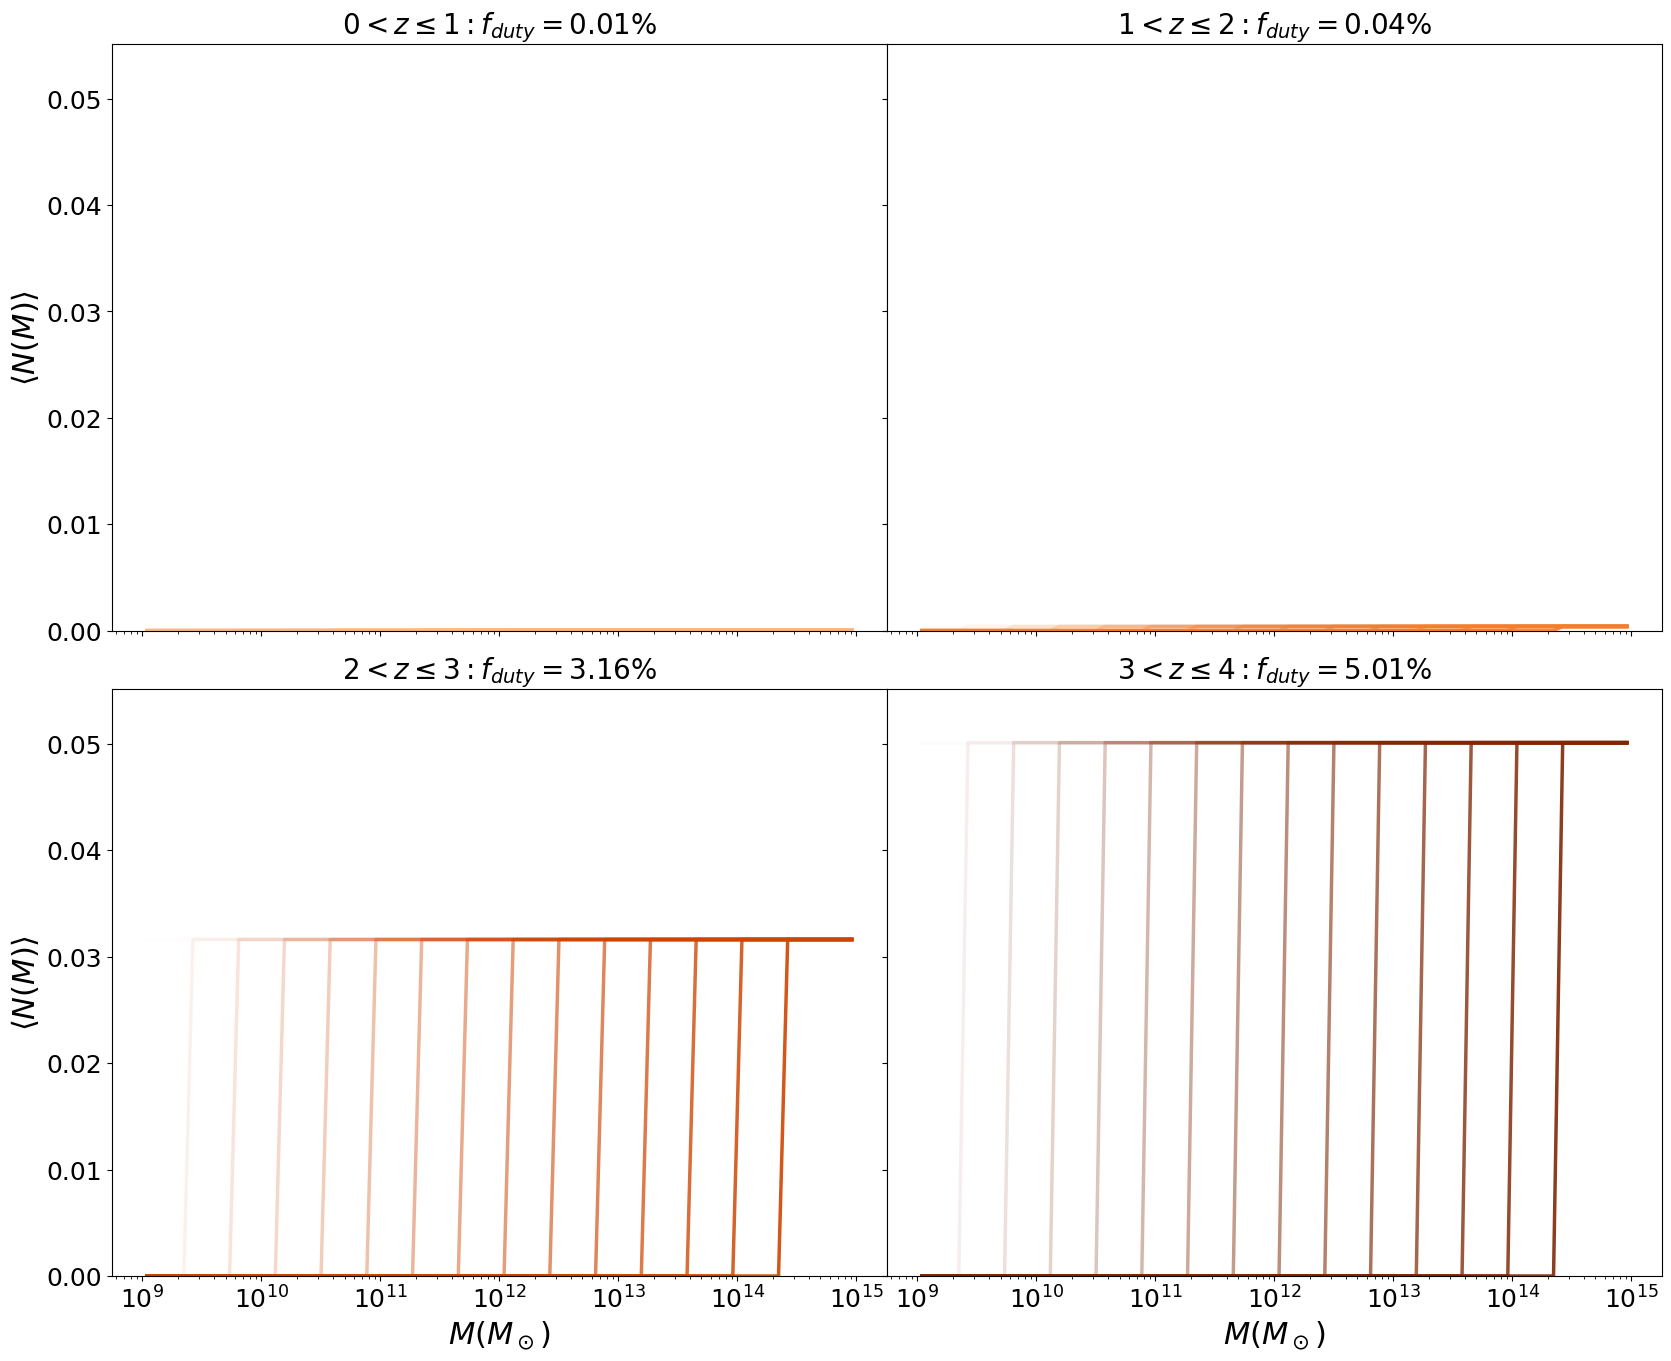

In [41]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
k = 5
# f = np.sort(np.random.randint(0, len(fduty_array), size = len(z_array)))
rng = np.random.default_rng()
f = np.sort(rng.choice(len(fduty_array), size = len(z_array), replace = False))

for i in z_array:

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(int(len(bins)/k)):
        
        ax1.plot(quaia.recenter(bins), n_m_array_3D[i][j*k][f[i]], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), 
                 color = cmap_qq[i], alpha = (j*k+1)/len(bins))

    ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%$'.format(i, i+1, fduty_array[f[i]]*100))
    # ax1.set_title('${:.0f}<z \leq{:.0f}: \log_{{10}}(f_{{duty}})={:.2f}$'.format(i, i+1, np.log10(fduty_array[f[i]])))
    # ax1.set_title('${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2e}$'.format(i, i+1, fduty_array[f[i]]))
    ax1.set_xscale('log')
    ax1.set_ylim(0, 1.1*np.max(fduty_array[f]))

    if i>1:
        ax1.set_xlabel('$M (M_\odot)$')
    else:
        ax1.set_xticklabels([])
    if i%2 == 0:
        ax1.set_ylabel(r'$\langle N(M) \rangle$')
    else:
        ax1.set_yticklabels([])

plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:15: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/3038851972.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(bins), n_m_array_3D[i][l][j*k], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i],
/tmp/ipykernel_38900/3038851972.py:15: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.0f}<z \leq{:.0f}: M_{{min}}={:.2f} M_{{\odot}}$'.format(i, i+1, np.log10(bins[l])))
/tmp/ipykernel_38900/3038851972.py:20: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_xlabel('$M (M_\odot)$')


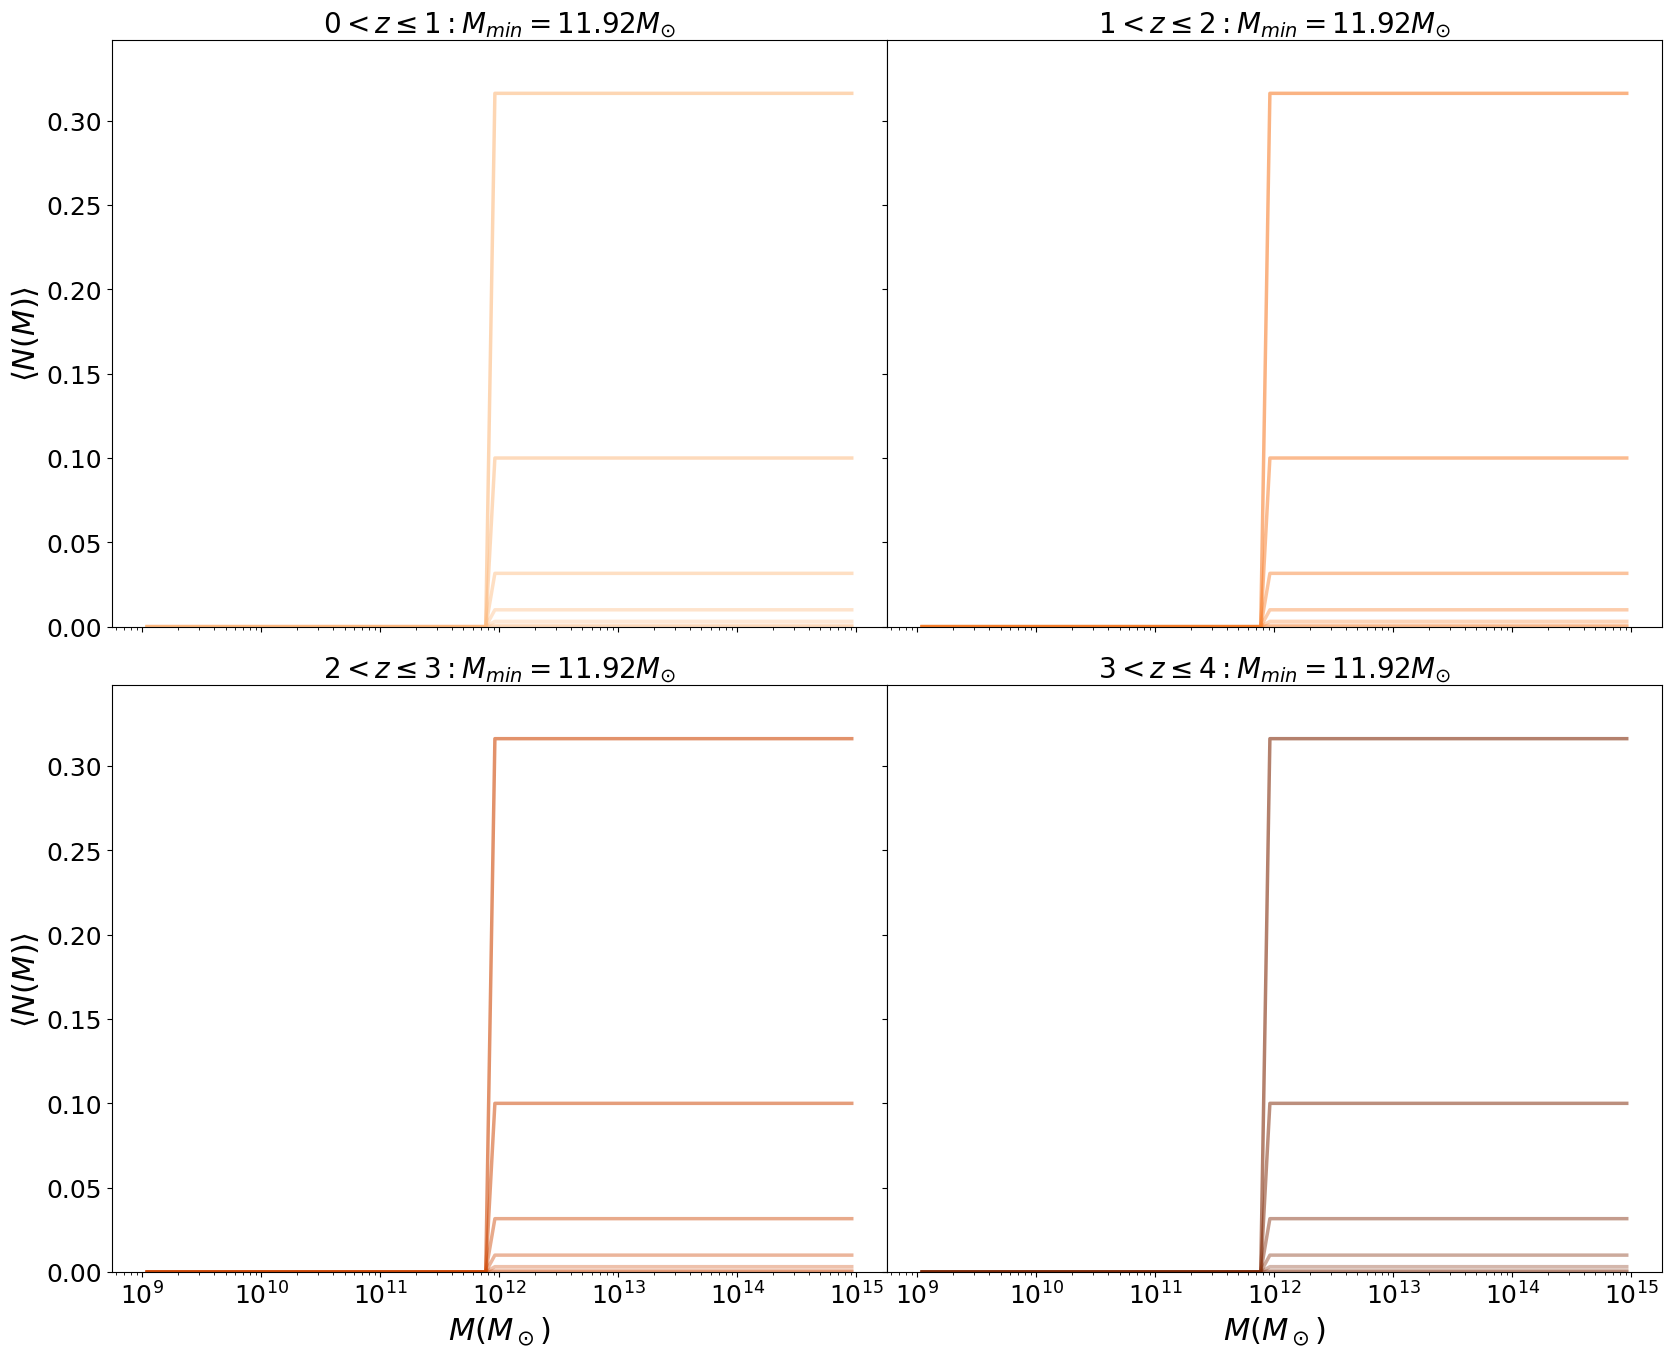

In [42]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
k = 5
l = 38 # 25

for i in z_array:

    ax1 = fig.add_subplot(gs[i])
    
    for j in range(int(len(fduty_array)/k)):
        
        ax1.plot(quaia.recenter(bins), n_m_array_3D[i][l][j*k], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i], 
                 alpha = (j*k+1)/len(bins))

    ax1.set_title('${:.0f}<z \leq{:.0f}: M_{{min}}={:.2f} M_{{\odot}}$'.format(i, i+1, np.log10(bins[l])))
    ax1.set_xscale('log')
    ax1.set_ylim(0, 1.1*fduty_array[j*k])

    if i>1:
        ax1.set_xlabel('$M (M_\odot)$')
    else:
        ax1.set_xticklabels([])
    if i%2 == 0:
        ax1.set_ylabel(r'$\langle N(M) \rangle$')
    else:
        ax1.set_yticklabels([])

plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [43]:
linestyles = ['-', '--']

cf_zbin_percentile, cf_matter_zbin_percentile = [], []
yerr_cf, b_cf = [], []
a_zbin, b_cf_q = [], []
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins, Om0 = Planck18.Om0, h = Planck18.h, error = True)
    cf_zbin_percentile.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function
    H0 = Planck18.H(0)
    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a)
    cf_matter_zbin_percentile.append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf.append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf.append(yerr)

    # qso bias
    b_cf_q.append(b_qso(cf, cf_matter, ccl.growth_rate(cosmo_planck18, a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_38900/7427029.py:30: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_38900/7427029.py:34: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_38900/7427029.py:35: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_38900/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_38900/7427029.py:30: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_38900/7427029.py:34: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_38900/7427029.py:35: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_38900/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_38900/7427029.py:30: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_38900/7427029.py:34: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_38900/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin3.0zmax4.6: 0.21              28786 vs 36458


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_38900/7427029.py:30: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_38900/7427029.py:34: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_38900/7427029.py:35: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_38900/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


## Measure $\xi(s)$ and calculate the two-halo term: $\xi_{2 h}(r) \approx\left[n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle b_h(M)\right]^2 \xi_m(r)$
###  Implement Poisson error bars: $\Delta \xi(s)=\begin{cases}\frac{1+\xi(s)}{\sqrt{DD(s)}} & \xi(s)\geq 0 \\ \sqrt{\frac{1+\xi(s)_\mathrm{model}}{D R}} & \xi(s)<0\end{cases}$ 

In [44]:
b_eff_cf20 = np.load('../results/b_eff_cf20_planck18.npy')
b_eff_wp20 = np.load('../results/b_eff_wp20_planck18.npy')

In [45]:
bins_M_min = np.logspace(M_min, M_max, 79)

In [46]:
fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_38900/3300739735.py:21: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])


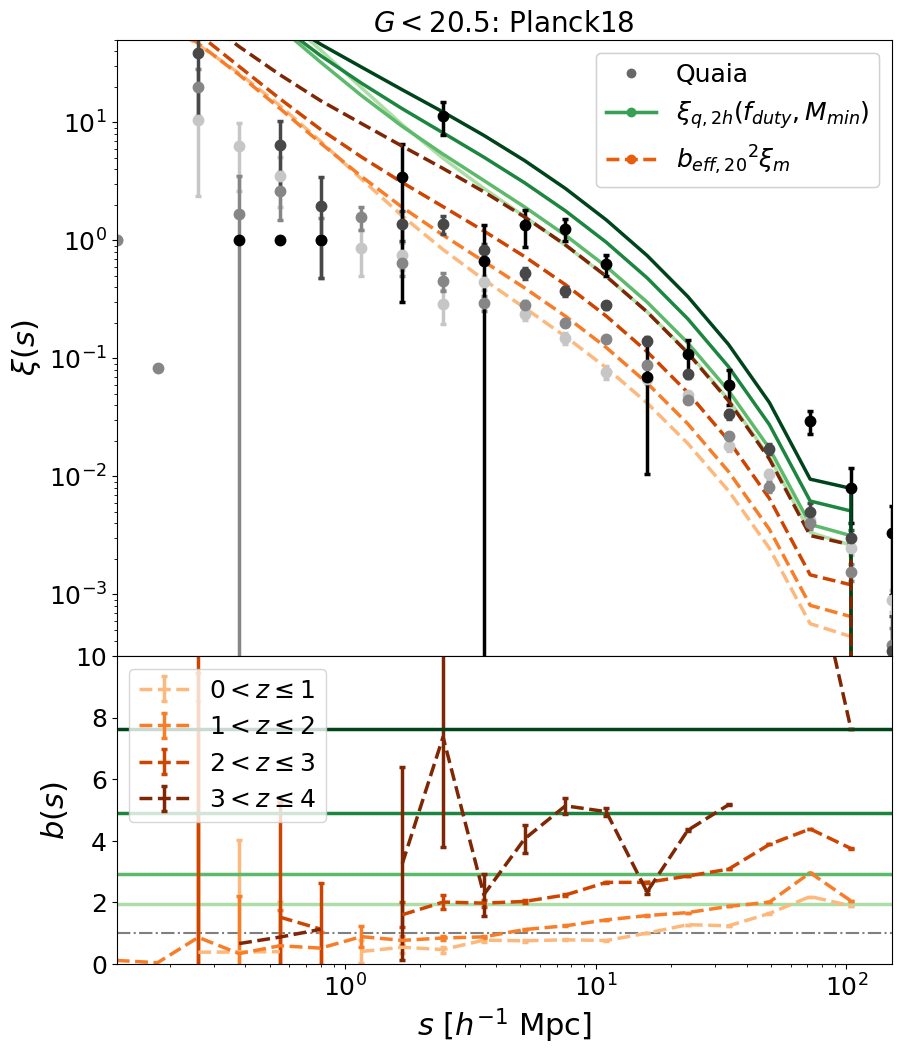

In [47]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
N = 25
i = 1
for j in z_array:

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_b[j], 
                 yerr = yerr_cf[j], linestyle = 'none', markeredgewidth = 2.5, capsize = 2.5) #  markerfacecolor = 'white'
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'\xi_2h}',
             color = cmap_mm[j], linestyle = '-')
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[j], linewidth = 2.5, linestyle = '--',
             label = r'$b_{20}$ model', color = cmap_qq[j])

    ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, capsize = 2.5, markeredgewidth = 2.5, linestyle = '--',
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
    ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])
    
ax1.set_title('$G<{}$: Planck18'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
                Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, ['Quaia', r'$\xi_{q,2h}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '-.', color = 'black', zorder = 0, alpha = 0.5)
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 10)
ax2.legend()

ax1.set_ylabel(r'$\xi(s)$')
ax2.set_ylabel(r'$b(s)$')

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_38900/92696897.py:19: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
/tmp/ipykernel_38900/92696897.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


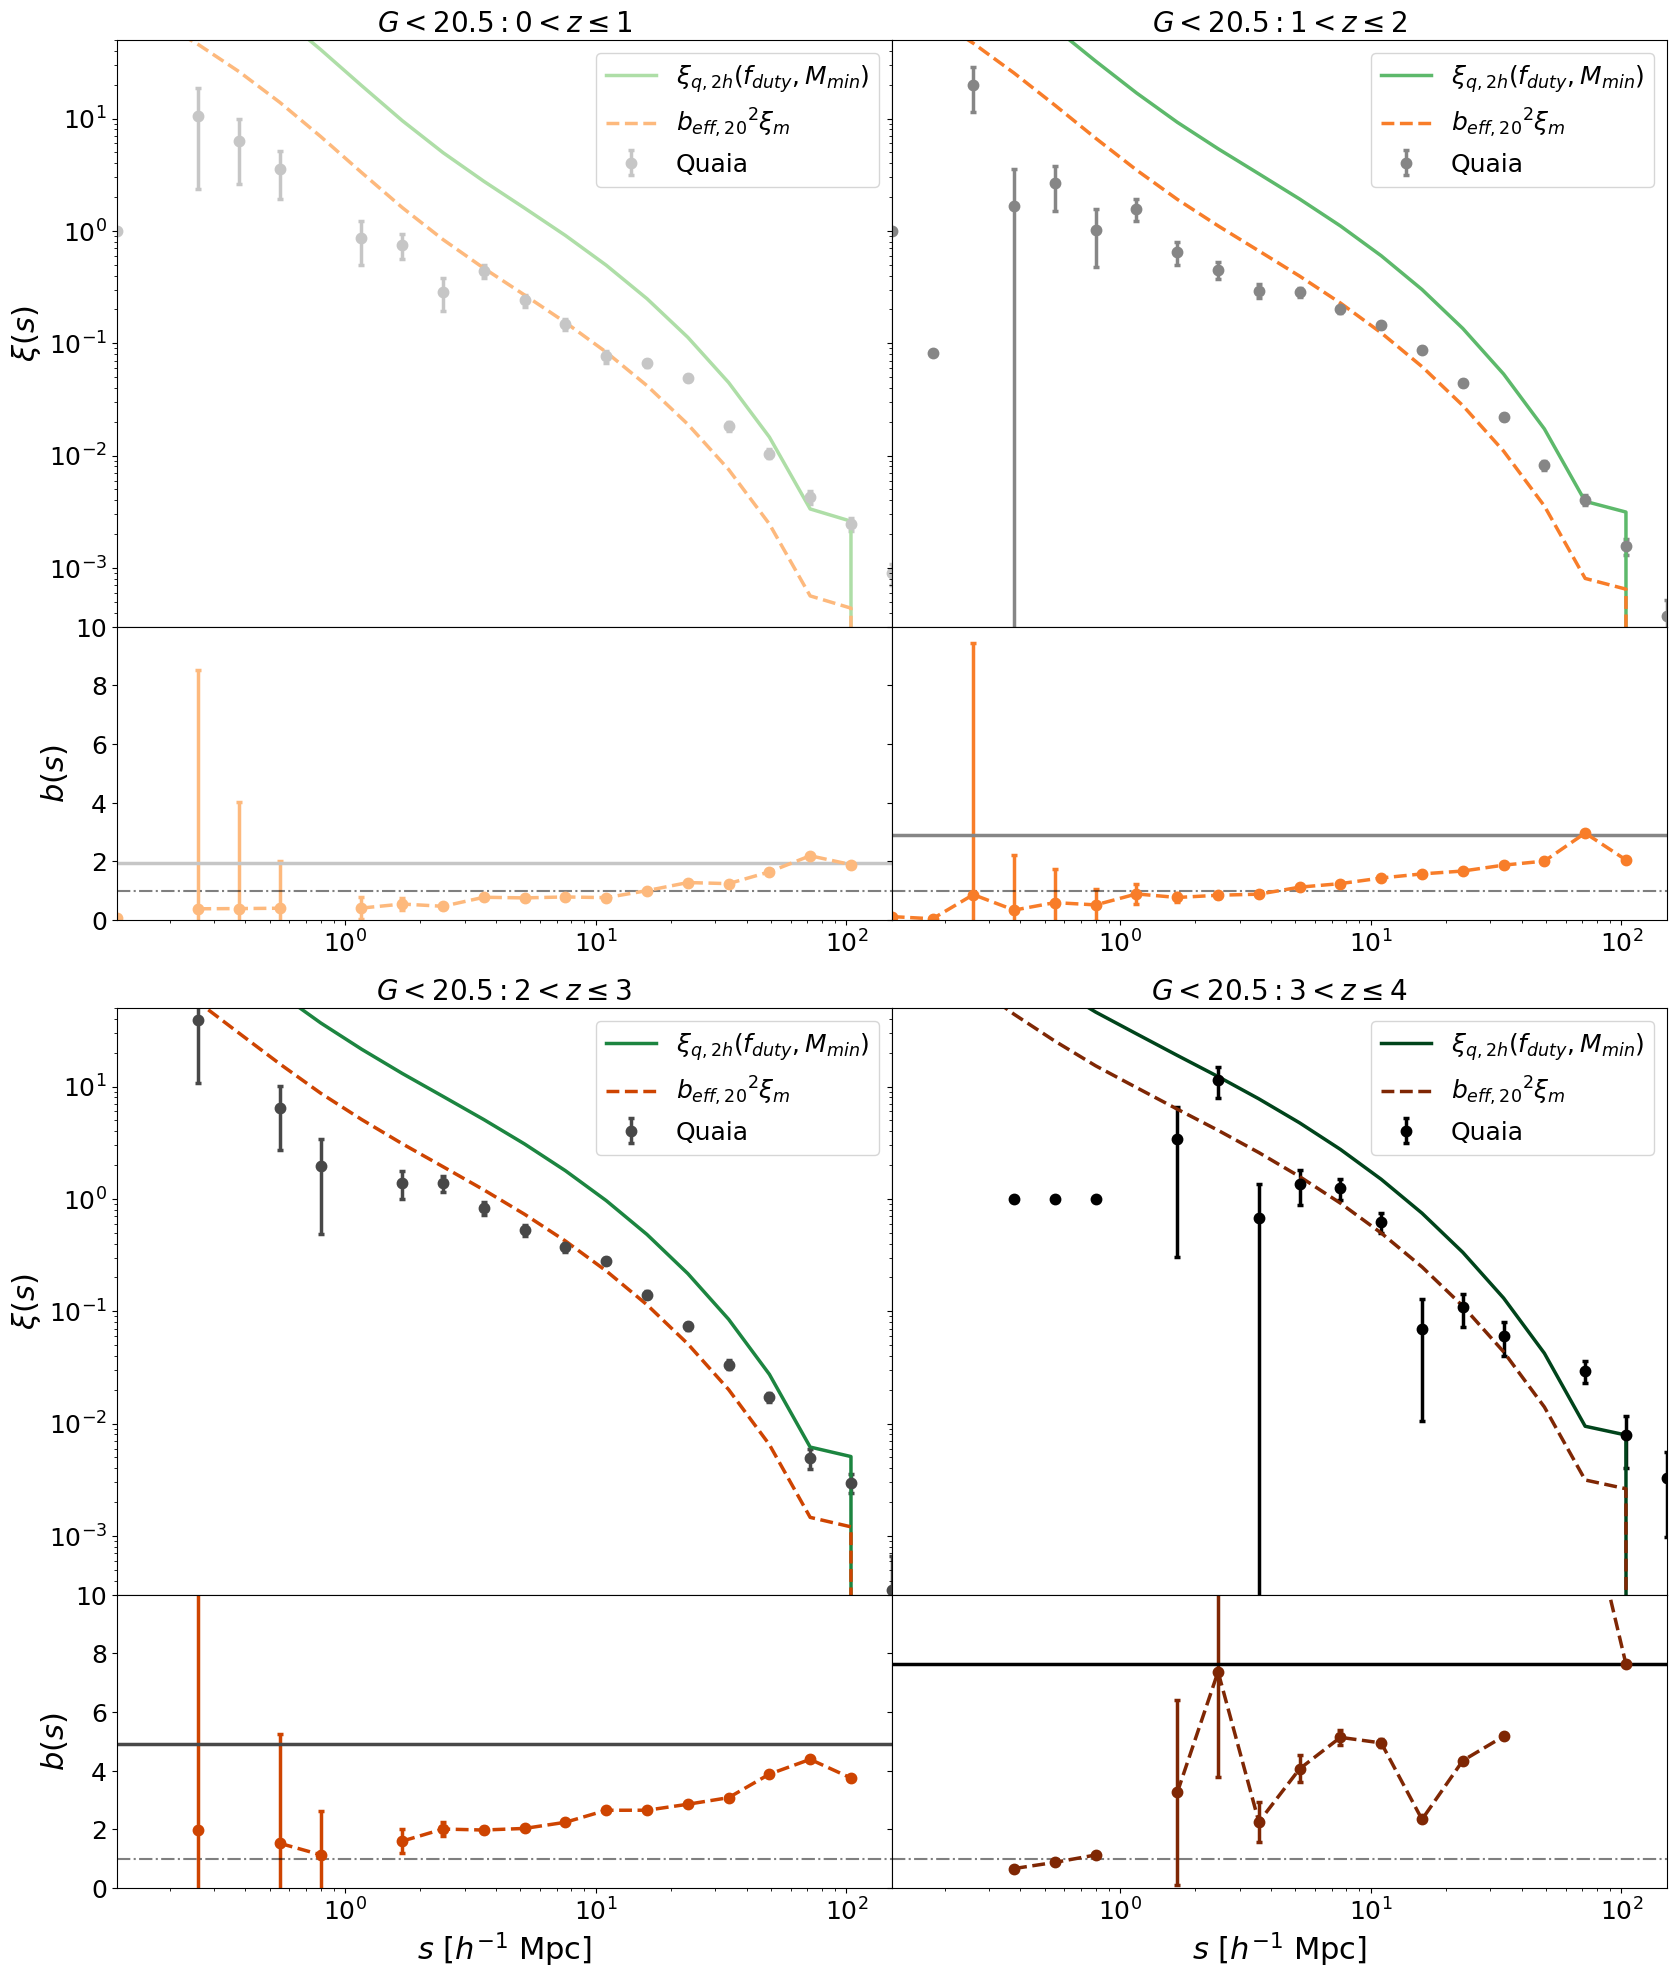

In [48]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
            
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_b[j],
                yerr = yerr_cf[j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'$\xi_{q,2h}(f_{duty}, M_{min})$',
             color = cmap_mm[j])
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = cmap_qq[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, marker = 'o', linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
    ax2.axhline(b_q, linewidth = 2.5, color = cmap_b[j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

### Vary $M_{min}$

In [49]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

In [50]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_38900/4129793462.py:26: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


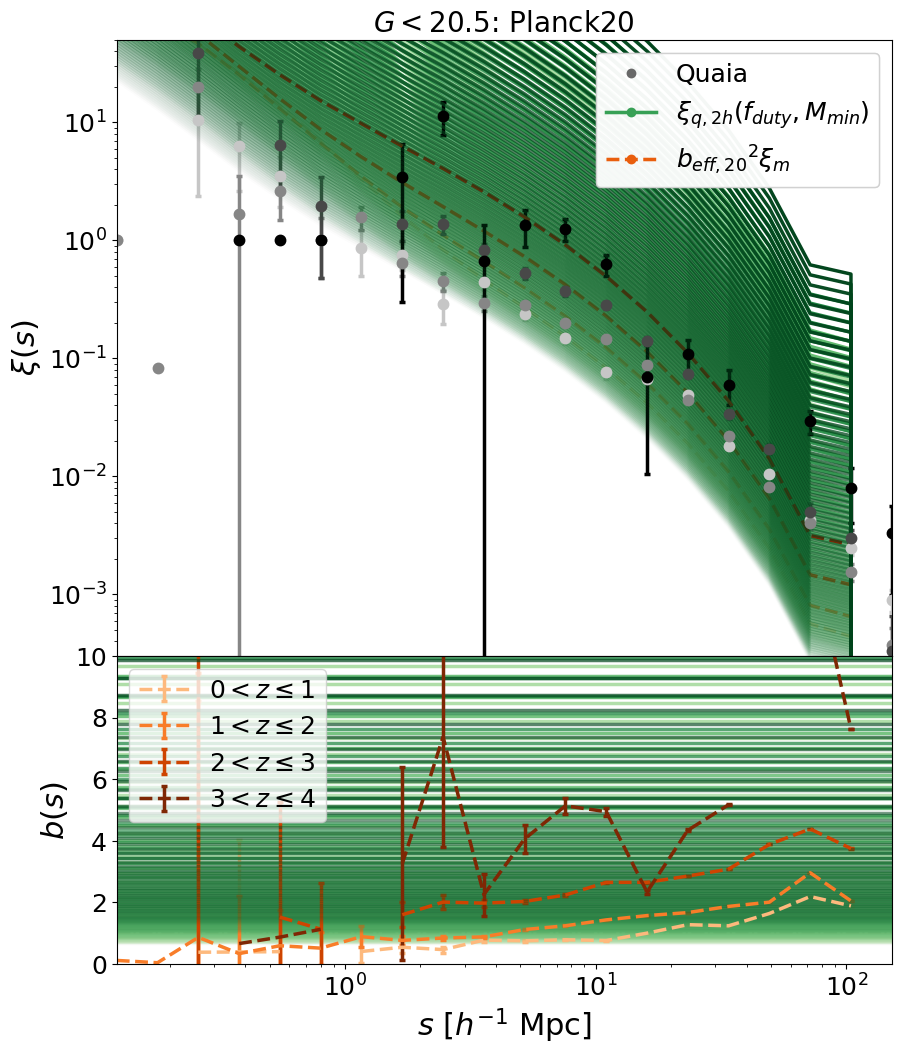

In [51]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

i = 1
for j in z_array:

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_b[j], 
                 yerr = yerr_cf[j], linestyle = 'none', markeredgewidth = 2.5, capsize = 2.5) #  markerfacecolor = 'white'
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[j], linewidth = 2.5, linestyle = '--',
             label = r'$b_{20}$ model', color = cmap_qq[j])
    
    for k in range(len(bins)):
        
        cf_2h_zbin, b_q = cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j],
                                recenter = False)
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'\xi_2h}',
             color = cmap_mm[j], linestyle = '-', alpha = (k+1)/len(bins))
        ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j],  alpha = (k+1)/len(bins))

    ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, capsize = 2.5, markeredgewidth = 2.5, linestyle = '--',
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[j])
    
ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
                Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, ['Quaia', r'$\xi_{q,2h}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '-.', color = 'black', zorder = 0, alpha = 0.5)
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 10)
ax2.legend()

ax1.set_ylabel(r'$\xi(s)$')
ax2.set_ylabel(r'$b(s)$')

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

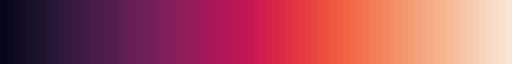

In [52]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

<>:73: SyntaxWarning: invalid escape sequence '\o'
<>:73: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/3592762041.py:73: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: divide 

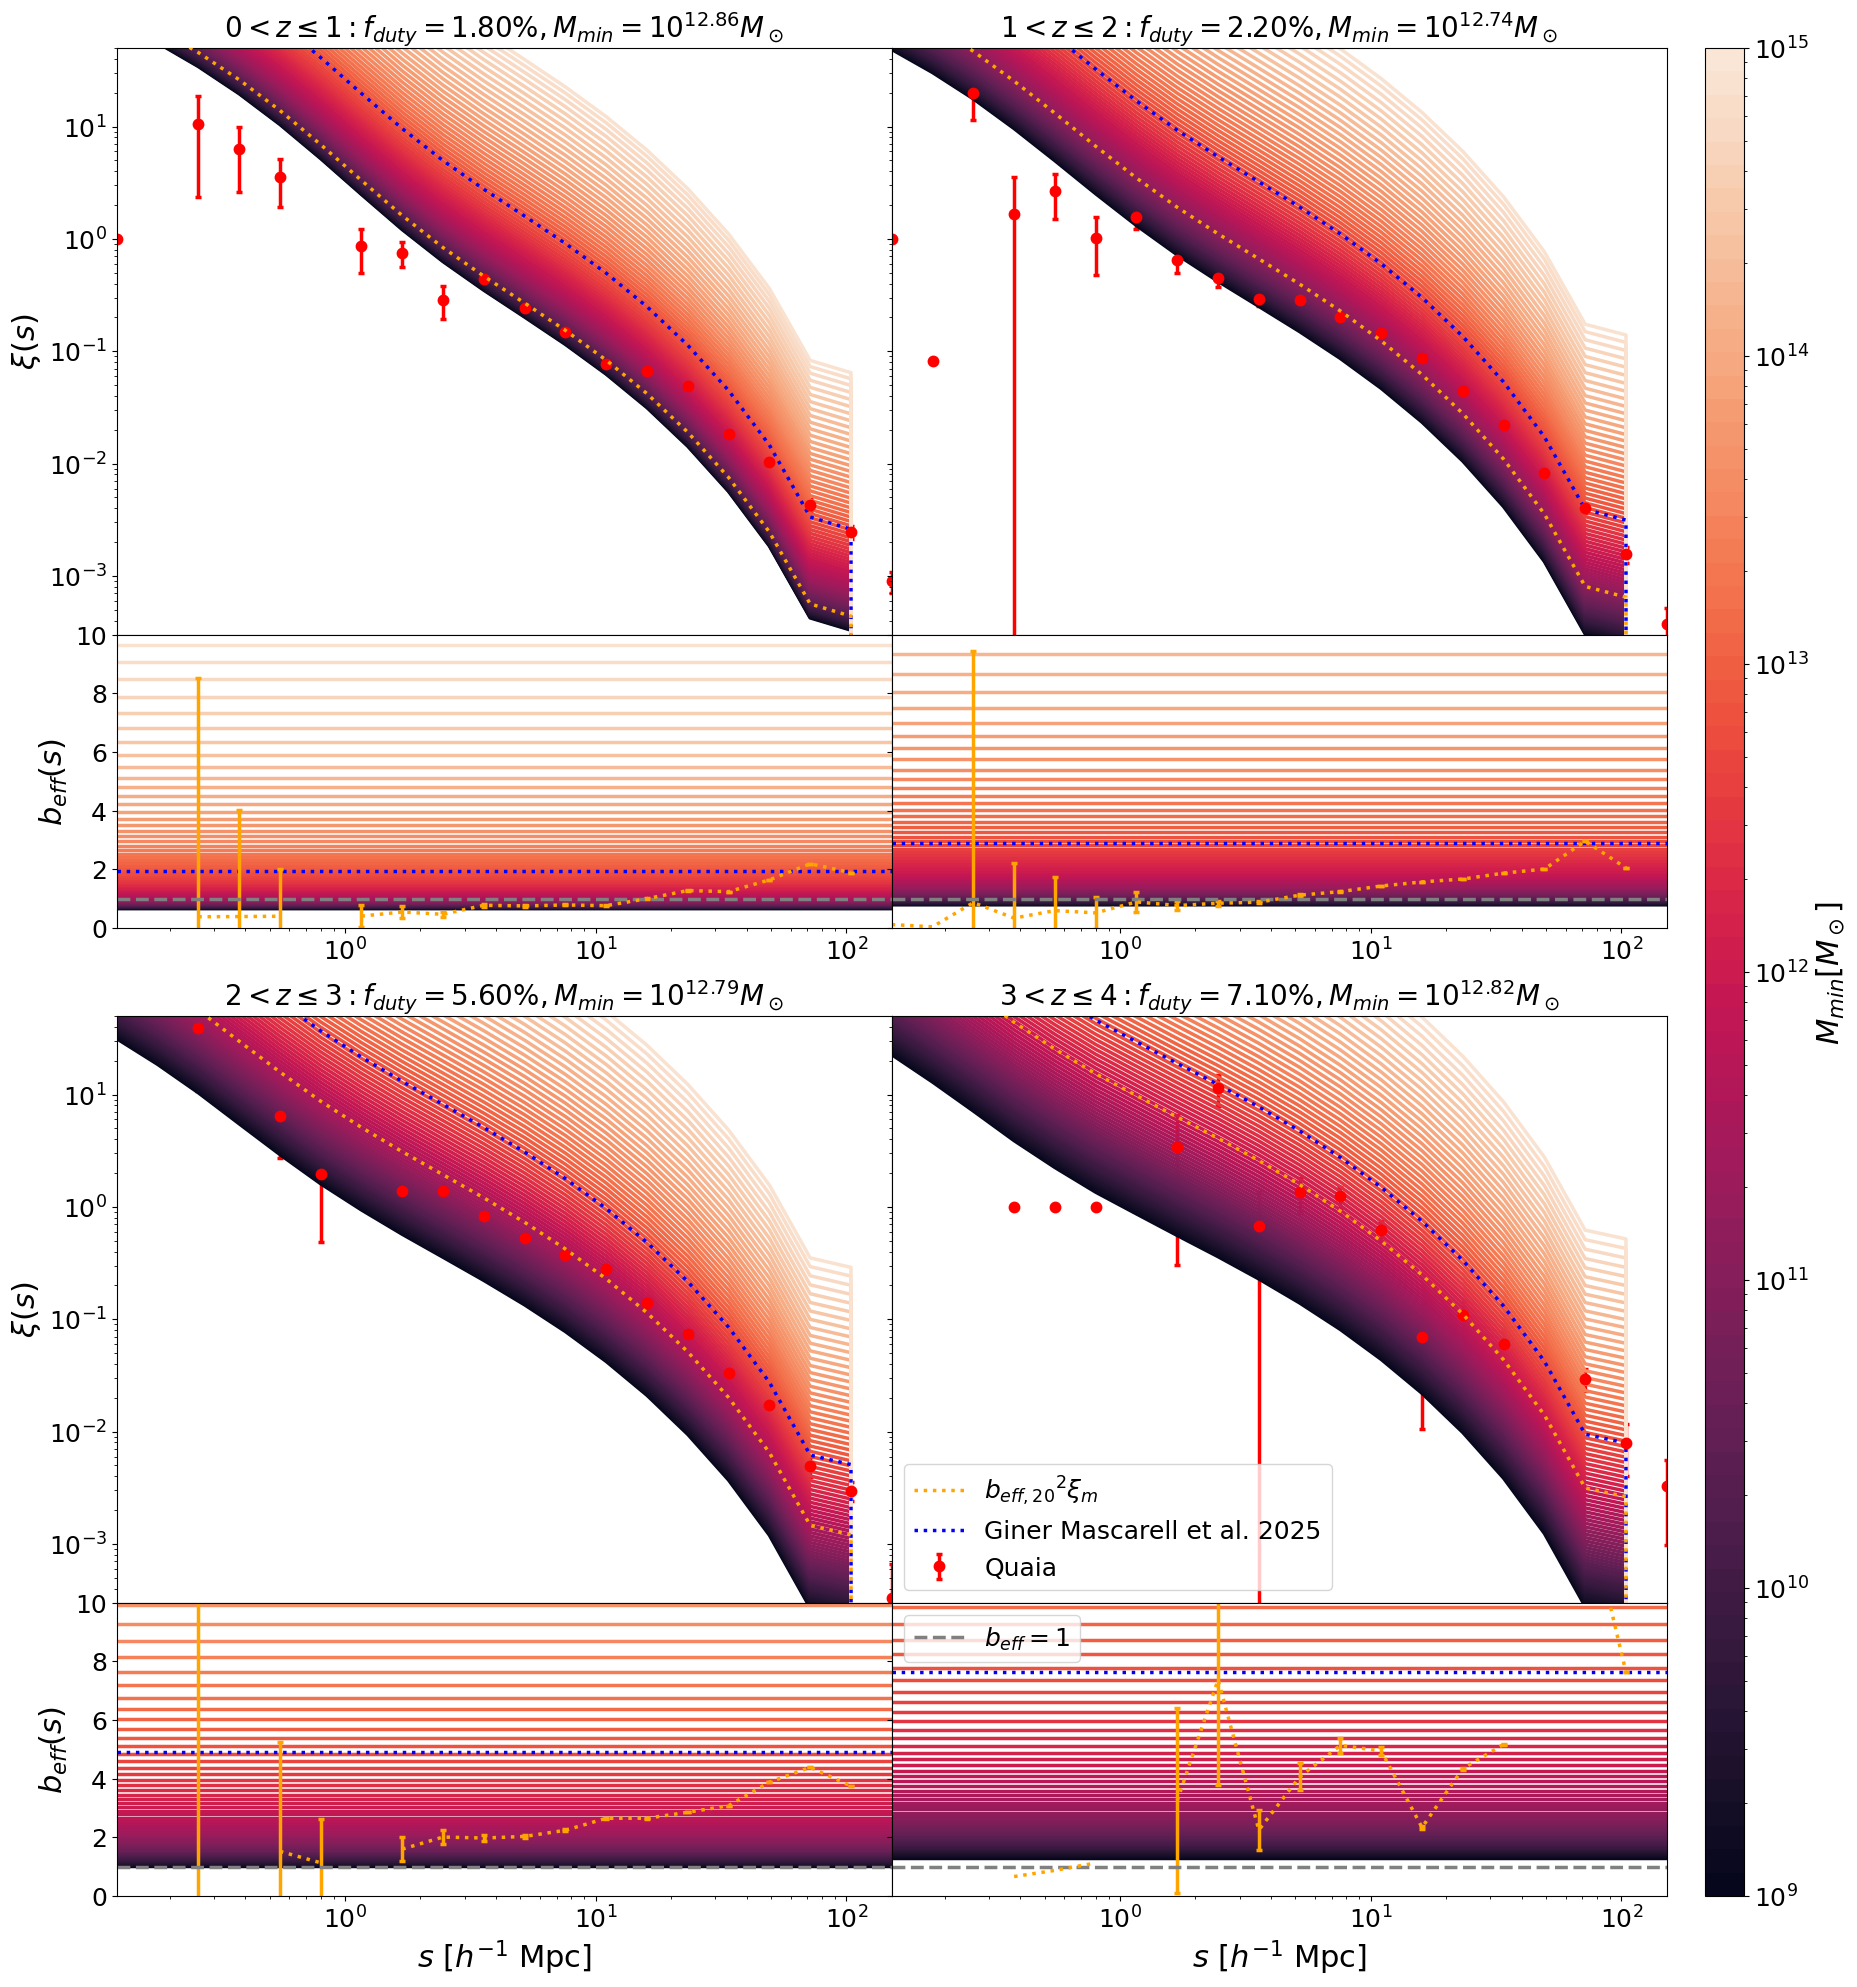

In [53]:
fig = plt.figure(figsize = (21, 24))
gs = gridspec.GridSpec(5, 4, height_ratios = [1, 0.5, 0.15, 1, 0.5], width_ratios = [1, 1, 0.05, 0.05], hspace = 0, wspace = 0)
ax1_idx = [0, 1, 12, 13]
ax2_idx = [4, 5, 16, 17]
k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[ax1_idx[j]])
    ax2 = fig.add_subplot(gs[ax2_idx[j]])
            
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red', 
                yerr = yerr_cf[j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')    #color = cmap_b[j],
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = ':', zorder = 3)

    for l in range(len(bins)):

        # print(np.log10(bins[l]), (l+1)/len(bins))
        cf_2h_zbin, b_q = cf_2h(bins_M_min_array[l], n_m_array_2D[j][l], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], 
                                recenter = False)
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, color = cmap[l], linewidth = 2.5)
             # color = cmaps[i][j], alpha = (l+1)/len(bins))
        ax2.axhline(b_q, color = cmap[l], linewidth = 2.5) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, color = 'blue', label = "Giner Mascarell et al. 2025", linestyle = ':')
             # label = '$\log_{{10}}(M_{{min}}/M_\odot) = {:.2f}$'.format(M_min), linestyle = ':')
    ax2.axhline(b_q, linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

    ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, linestyle = ':', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'orange', yerr = yerr_cf[j])

    if (j + k) % 6 < 2:
        ax1.set_title(r'${:.0f}<z \leq{:.0f}: f_{{duty}}={:.2f}\%, M_{{min}}=10^{{{:.2f}}} M_\odot$'.format(j, j+1, fduty[j]*100, M_min_array[j]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    ax2.axhline(1, linestyle = '--', color = 'grey', linewidth = 2.5, label = '$b_{eff}=1$')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b_{eff}(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

# custom_lines = [Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'none', linewidth = 2.5),
#                 # Line2D([0], [0], color = 'orange', marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = 'orange', marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, ['Quaia', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right') # r'$\xi_{q,2h}(f_{duty}, M_{min})$', 
# ax1.add_artist(second_legend)

ax1.legend()
ax2.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

# Calculate derived parameters
## Plot b(z)

In [54]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck20): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [55]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

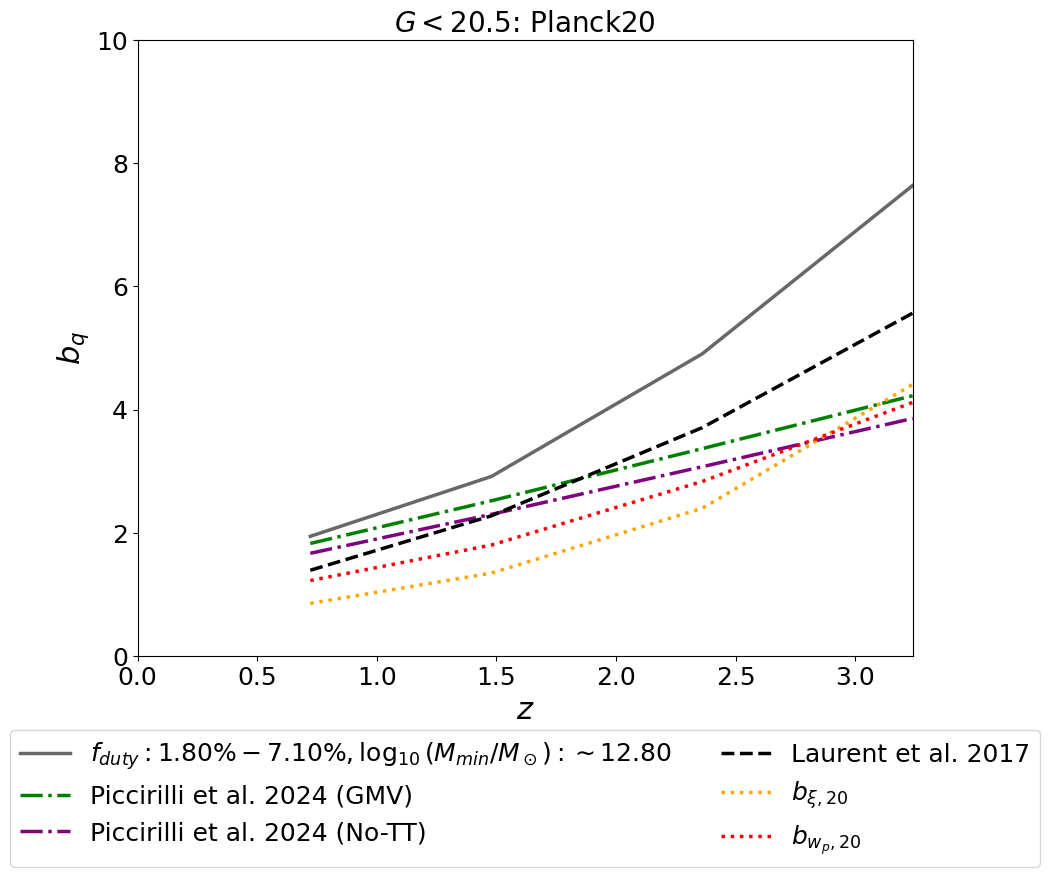

In [56]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
i = 1

b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], 
             recenter = False)[1] for j in z_array]
zbin = 1/np.array(a_zbin)-1
plt.plot(zbin, b_q, linewidth = 2.5, color = grey,
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, \log_{{10}}(M_{{min}}/M_\odot):\sim{:.2f}$'.format(fduty[0]*100, fduty[-1]*100, M_min))
plt.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
plt.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
plt.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

plt.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
plt.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

plt.title('$G<{}$: {}'.format(G_hi, labels[i]))

plt.xlabel('$z$')
plt.ylim(0, 10)
plt.xlim(0, zbin[-1])
plt.ylabel(r'$b_q$')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')

plt.show()

### Vary $M_{min}$

<>:46: SyntaxWarning: invalid escape sequence '\o'
<>:46: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/1304014471.py:46: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


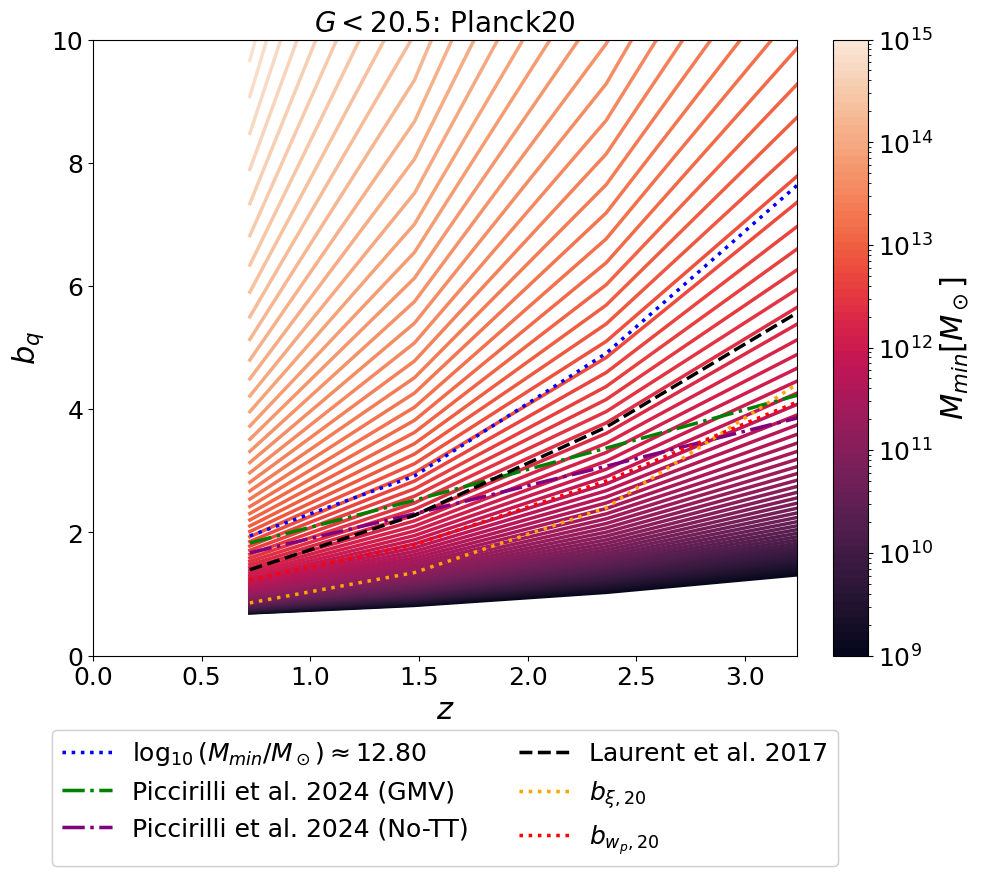

In [57]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    b_q = [cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j],
                 recenter = False)[1] for j in z_array]
    zbin = 1/np.array(a_zbin)-1
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap[k]) #grey,
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j],
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(0, zbin[-1])
ax1.set_ylabel(r'$b_q$')
# plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx {:.2f}$'.format(M_min), 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 'Laurent et al. 2017',
                                          r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

# cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.BoundaryNorm(np.log10(bins), palette.N)), cax = fig.add_subplot(gs[:,-1]), label = '$\log_{10}(M_{min}/M_\odot)$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
# cbar.set_label('$\log_{10}(M_{min}/M_\odot)$')
plt.show()

## Calculate halo mass as $\langle M \rangle \approx n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle M$

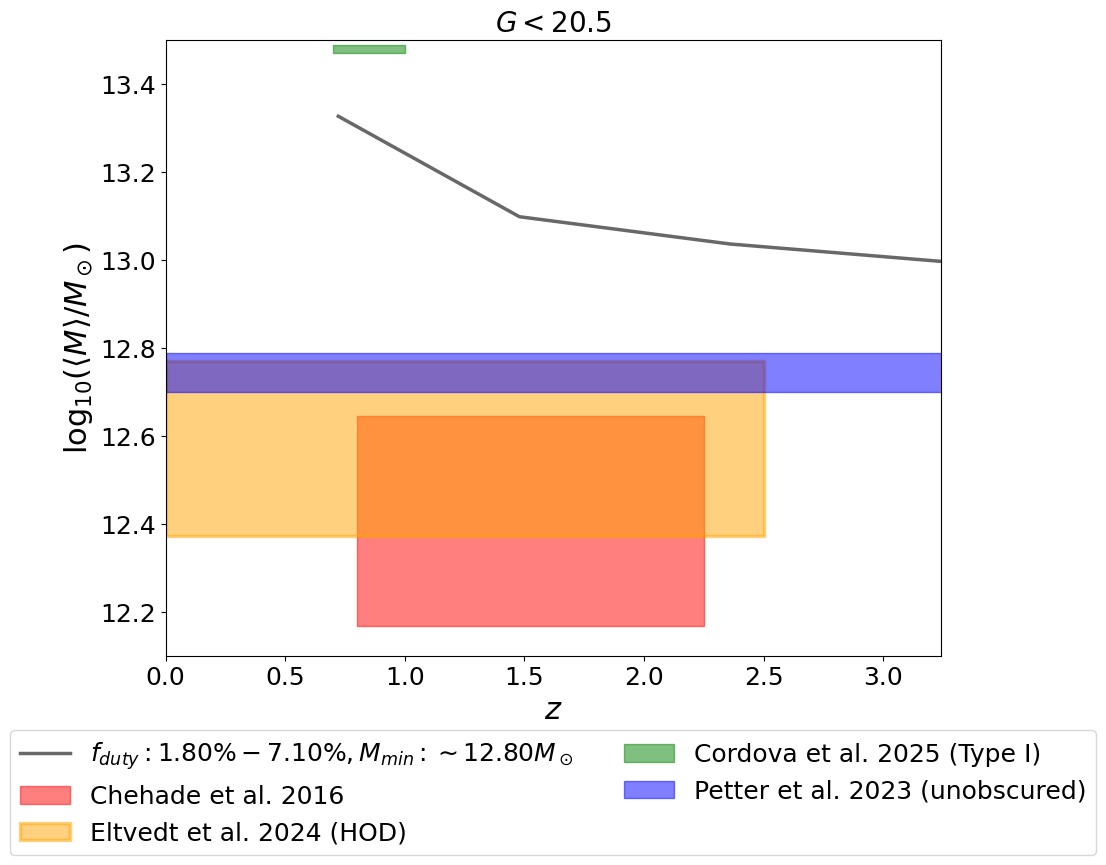

In [58]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
i = 1

M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
plt.plot(zbin, np.log10(M_h), linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, M_min), color = grey)
z = np.linspace(0.8, 2.25)
plt.fill_between(z, [np.log10(1e12/cosmo_planck18['h'])]*len(z), [np.log10(3e12/cosmo_planck18['h'])]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
plt.title('$G<{}$'.format(G_hi))
plt.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo_planck18['h'])]*len(z), [np.log10(4e12/cosmo_planck18['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
plt.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
plt.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo_planck18['h'])]*len(z), [np.log10(10**12.62/cosmo_planck18['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

plt.xlabel('$z$')
plt.ylim(12.1, 13.5)
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
plt.ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
plt.xlim(0, zbin[-1])
plt.show()

### Vary $M_{min}$

<>:48: SyntaxWarning: invalid escape sequence '\o'
<>:48: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/3932160938.py:48: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)


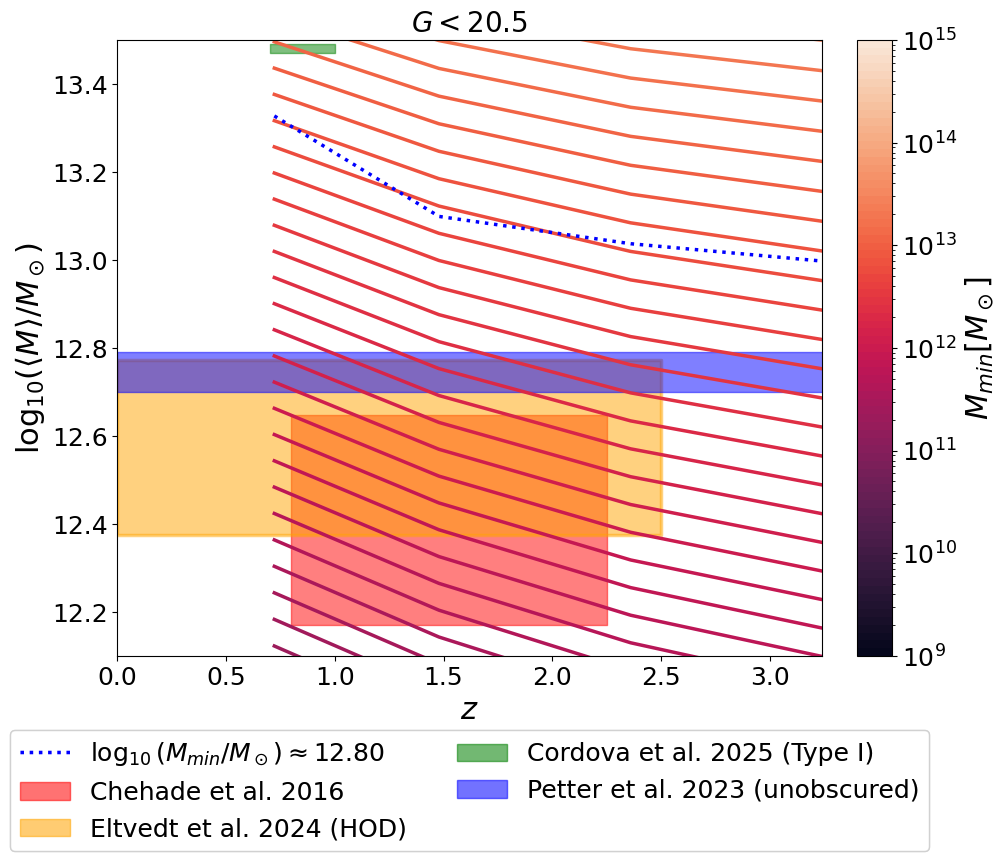

In [59]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1

for k in range(len(bins)):
    
    M_h = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap[k]) #, alpha = (1+k)/len(bins))
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
    
z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/cosmo_planck18['h'])]*len(z), [np.log10(3e12/cosmo_planck18['h'])]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo_planck18['h'])]*len(z), [np.log10(4e12/cosmo_planck18['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo_planck18['h'])]*len(z), [np.log10(10**12.62/cosmo_planck18['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min),
                           # [r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, 
                                                                                                          # np.log10(bins[0]), np.log10(bins[-1])), 
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

# patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
# first_legend = ax1.legend(handles=patch, loc = 'lower left')
# ax1.add_artist(first_legend)

ax1.set_xlabel('$z$')
# plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(12.1, 13.5)

# cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.BoundaryNorm(np.log10(bins), palette.N)), cax = fig.add_subplot(gs[:,-1]), label = '$\log_{10}(M_{min}/M_\odot)$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [60]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508
G20.5_zmin3.0zmax4.6: 0.21              28786 vs 36458


In [61]:
n_q, n_q_err = [], []

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
    print(f_sky)
    zmax = quaia.comoving_dist(j+1, h = cosmo_planck18['h'], Om0 = cosmo_planck18['Omega_m']).value #) cosmos[i]['Omega_m']+cosmos[i]['Omega_c']).value # Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo_planck18['h'], Om0 = cosmo_planck18['Omega_m']).value #cosmos[i]['Omega_b']+cosmos[i]['Omega_c']).value # Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) #*cosmo_quaia['h']**3 # convert to 1/Mpc^3
    
    n_q.append(N/V)
    n_q_err.append(np.sqrt(N)/V) # Poisson error

0.29746390823822866
0.3229221159273539
0.2744938755620083
0.2518852527362318


### Compute the maximum number of jackknife regions

In [62]:
for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_hi_bins[j]>=cp]*hp.nside2pixarea(NSIDE))
    zmax = quaia.comoving_dist(j+1, h = cosmo_planck18['h'], Om0 = cosmo_planck18['Omega_m']).value # Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo_planck18['h'], Om0 = cosmo_planck18['Omega_m']).value # Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3))
    V_jackknife = f_sky*(4/3*np.pi*(80**3))
    print(np.int(V/V_jackknife), (V/25)**(1/3))

23515 843.463674453357
66041 1223.048185967541
74956 1208.5200572156941
70976 1153.2182905918912


### Test method against Storey-Fisher et al. 2023

In [63]:
tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [0], True, ['z'], 
                                                                                     bins = [None], tab_gcat_type = 'data',
                                                                                     method = [None], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

Leaving tab_gcat_catalog unbinned
G20.5: 0.28              938957 vs 1295502


In [64]:
# cp = np.percentile(selfunc_hi_bin0, mask*100)
cp = 0
f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bin0[selfunc_hi_bin0>=cp]*hp.nside2pixarea(NSIDE))
print(f_sky)

0.4789816662703589


### Check against $V_{eff}$

In [65]:
r = quaia.comoving_dist(tab_datahi_mask_zbin0['redshift_quaia'], h = cosmo_planck18['h'], 
                        Om0 = cosmo_planck18['Omega_m']) #cosmo_planck20['Omega_b']+cosmo_planck20['Omega_c'])
V = f_sky*(4/3*np.pi*(np.max(r)**3-np.min(r)**3))
V.to((u.Gpc/cu.littleh)**3) # i guess we expect a different result since kate said she calculated it differently?

<Quantity 284.59172282 Gpc3 / littleh3>

### Test method against Giner Mascarell et al. 2025

In [66]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
b = [0,0,0,30]
for j in z_array:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, selfunc_hi_bin0_mask_inv, _, selfunc_hi_bin0 = quaia.make_bins(G_hi, [j], True, ['z'],
                                                                                                                               mask_type = 'b', 
                                                                                                                               b = b[j],
                                                                                             bins = [z_bins], tab_gcat_type = 'data',
                                                                                             method = ['minmax'], fac_rand = 25,
                                                                                             n_bins = [None])
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

G20.5_zmin0.0zmax1.0: 0.00              324336 vs 324336
G20.5_zmin1.0zmax2.0: 0.00              648196 vs 648196
G20.5_zmin2.0zmax3.0: 0.00              286508 vs 286508
G20.5_zmin3.0zmax4.6: 0.22              28350 vs 36458


In [67]:
n_q_b, n_q_b_err = np.array([])/V.unit, np.array([])/V.unit
b = [0,0,0,30]

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    ra, dec = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat = True)
    c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)
    mask_datahi_bin0 = np.abs(c.galactic.b.value)>=b[j]
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][mask_datahi_bin0]*hp.nside2pixarea(NSIDE))
    zmax = quaia.comoving_dist(j+1, h = cosmo_planck18['h'], Om0 = cosmo_planck18['Omega_m']) #Mpc/h
    zmin = quaia.comoving_dist(j, h = cosmo_planck18['h'], Om0 = cosmo_planck18['Omega_m']) #Mpc/h
    V = f_sky*(4/3*np.pi*(zmax**3-zmin**3)) 
    n_q_b = np.append(n_q_b,N/V)
    n_q_b_err = np.append(n_q_b_err,np.sqrt(N)/V) # Poisson error

### Try directly reproducing Giner Mascarell et al. 2025 constraints

In [68]:
zbin_eff = [0.5, 1.5, 2.5, 3.5]
a_eff = 1/(1+np.array(zbin_eff))
hmf08 = ccl.halos.MassFuncTinker08()

# convert to (h/Mpc)^3 jk its already in (h/Mpc)^3
n_dm = np.array([n_DM(cosmo_planck18, a_eff[j], M_min_array[j], N = 100) for j in z_array])*(cu.littleh/u.Mpc)**3 
n_dm_08 = np.array([n_DM(cosmo_planck18, a_eff[j], M_min_array[j], N = 100, 
                         hmf = hmf08) for j in z_array])*(cu.littleh/u.Mpc)**3 

In [69]:
n_dm2 = 8.158e-04, 4.645e-04,8.703e-05, 1.073e-05

In [70]:
n_dm_err_hi = 7.867e-05, 2.959e-05, 1.122e-05, 5.418e-06
n_dm_err_lo = 1.090e-04, 3.135e-05, 8.270e-06, 1.526e-05

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_38900/1682403566.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$n_{DM} [(h\mathrm{Mpc}^{-1})^3]$')
/tmp/ipykernel_38900/1682403566.py:25: SyntaxWarning: invalid escape sequence '\D'
  ax2.set_ylabel('$\Delta n_{DM} [(h\mathrm{Mpc}^{-1})^3]$')


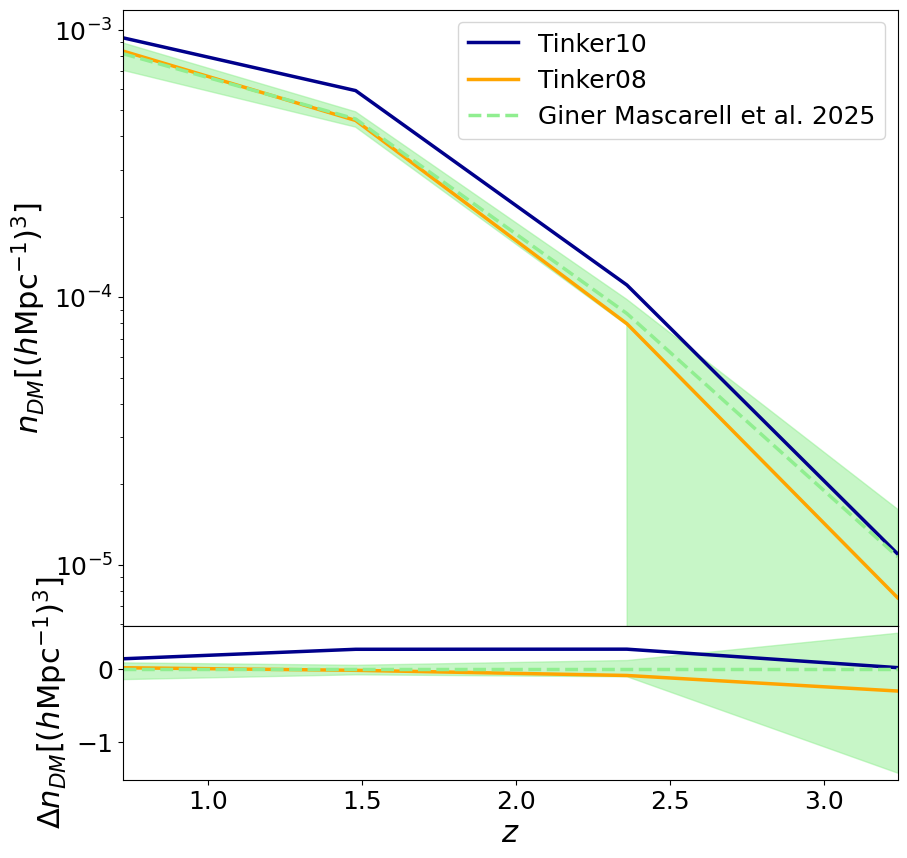

In [71]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.25], hspace = 0, wspace = 0)

ax1 = fig.add_subplot(gs[0])

ax1.plot(zbin, n_dm, color = 'darkblue', linewidth = 2.5, label = 'Tinker10')
ax1.plot(zbin, n_dm_08, color = 'orange', linewidth = 2.5, label = 'Tinker08')
ax1.plot(zbin, n_dm2, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')

n_dm_hi = np.add(n_dm2, n_dm_err_hi)
n_dm_lo = np.subtract(n_dm2, n_dm_err_lo)
ax1.fill_between(zbin, n_dm_hi, n_dm_lo, color = 'lightgreen', alpha = 0.5)
ax1.set_ylabel('$n_{DM} [(h\mathrm{Mpc}^{-1})^3]$')
ax1.set_xticklabels([])
ax1.legend()
# ax1.legend(bbox_to_anchor = (1.3, 0.5), loc='upper center')
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_yscale('log')

ax2 = fig.add_subplot(gs[1])
ax2.plot(zbin, (n_dm.value-n_dm2)/n_dm2, color = 'darkblue', linewidth = 2.5, label = 'Tinker10')
ax2.plot(zbin, (n_dm_08.value-n_dm2)/n_dm2, color = 'orange', linewidth = 2.5, label = 'Tinker08')
ax2.axhline(0, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
ax2.fill_between(zbin, np.array(n_dm_err_hi)/n_dm2, -np.array(n_dm_err_lo)/n_dm2, color = 'lightgreen', alpha = 0.5)
ax2.set_ylabel('$\Delta n_{DM} [(h\mathrm{Mpc}^{-1})^3]$')
ax2.set_xlabel('$z$')
ax2.set_xlim(zbin[0], zbin[-1])
plt.show()

In [72]:
fduty_check = n_q_b/n_dm
fduty_check2 = n_q_b/n_dm2
fduty_check_08 = n_q_b/n_dm_08

In [73]:
print("\n--- Quasar duty cycle per redshift bin ---")
header = (f"{'bin':>5} {'z_eff':>6} "
          f"{'n_QSO [h^3/Mpc^3]':>24} {'n_DM [h^3/Mpc^3]':>32} "
          f"{'f_duty':>14}")
print(header)
print("-" * len(header))

for j in range(len(zbin_eff)):
    print(f"{j+1:3d} {zbin_eff[j]:6.1f} "
          f"{n_q_b[j].value:18.3e}"
          f" (+/-{n_q_b_err[j].value:.3e})"
          f" {n_dm[j].value:18.3e} "
          f"{fduty_check_08[j]:20.3f} ")


--- Quasar duty cycle per redshift bin ---
  bin  z_eff        n_QSO [h^3/Mpc^3]                 n_DM [h^3/Mpc^3]         f_duty
-------------------------------------------------------------------------------------
  1    0.5          1.481e-05 (+/-2.601e-08)          9.350e-04                0.018 
  2    1.5          1.014e-05 (+/-1.259e-08)          5.931e-04                0.022 
  3    2.5          4.785e-06 (+/-8.940e-09)          1.113e-04                0.060 
  4    3.5          7.502e-07 (+/-4.456e-09)          1.099e-05                0.100 


In [74]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

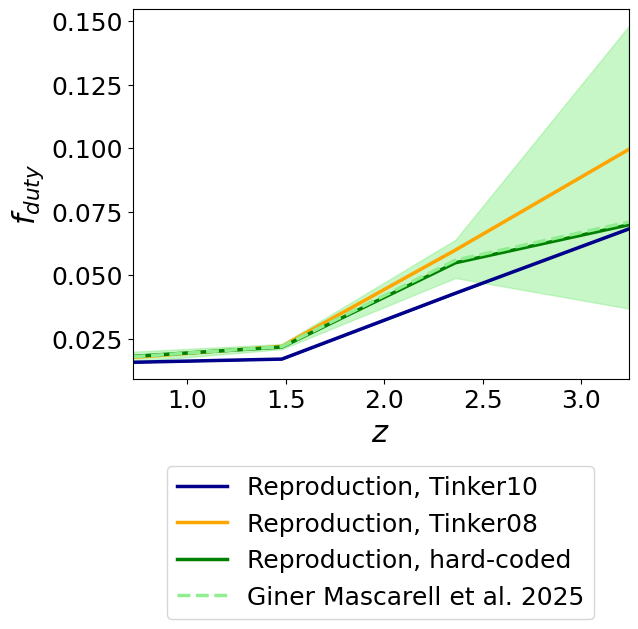

In [75]:
plt.plot(zbin, fduty_check, color = 'darkblue', linewidth = 2.5, label = 'Reproduction, Tinker10')
plt.fill_between(zbin, fduty_check+n_q_b_err.value, fduty_check-n_q_b_err.value, alpha = 0.5, color = 'darkblue')
plt.plot(zbin, fduty_check_08, color = 'orange', linewidth = 2.5, label = 'Reproduction, Tinker08')
plt.fill_between(zbin, fduty_check_08+n_q_b_err.value, fduty_check_08-n_q_b_err.value, alpha = 0.5, color = 'orange')
plt.plot(zbin, fduty_check2, color = 'green', linewidth = 2.5, label = 'Reproduction, hard-coded')
plt.plot(zbin, fduty, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.fill_between(zbin, np.array(fduty)+fduty_err_hi, np.array(fduty)-fduty_err_lo, alpha = 0.5, color = 'lightgreen')
# plt.ylabel('$\log_{10}(f_{duty})$')
plt.ylabel('$f_{duty}$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

### Plot

In [76]:
n_q_hi = np.array(fduty)*n_dm_hi
n_q_lo = np.array(fduty)*n_dm_lo

In [77]:
n_q_err_hi = n_q_hi*np.sqrt((np.array(n_dm_err_hi)/n_dm2)**2+(fduty_err_hi/fduty_check2.value)**2)
n_q_err_lo = n_q_lo*np.sqrt((np.array(n_dm_err_lo)/n_dm2)**2+(fduty_err_lo/fduty_check2.value)**2)

In [78]:
M_min_err_hi = 0.04, 0.02, 0.03, 0.10
M_min_err_lo = 0.05, 0.02, 0.03, 0.12

In [79]:
bins_M_min_hi, bins_M_min_lo = [], []
for i in z_array:   
    bins_M_min_hi.append(np.logspace(M_min_array[i]+np.array(M_min_err_hi), M_max, 79))
    bins_M_min_lo.append(np.logspace(M_min_array[i]-np.array(M_min_err_lo), M_max, 79))

In [80]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck20): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

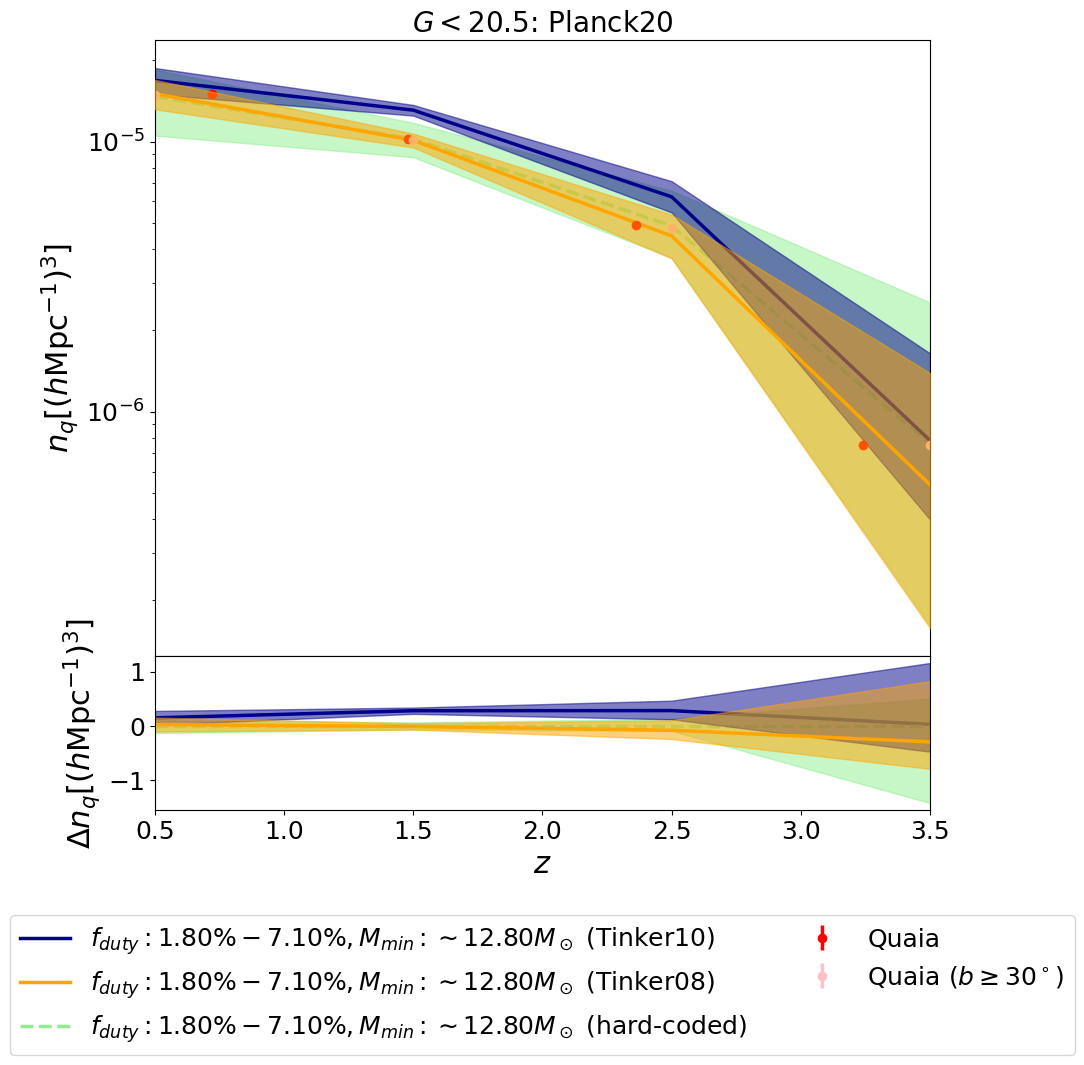

In [81]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.25], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
i = 1

ax1 = fig.add_subplot(gs[0])

n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.errorbar(zbin, n_q, linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = n_q_err, linestyle = 'None')
ax1.errorbar(zbin_eff, n_q_b, linewidth = 2.5, marker = 'o', label = r'Quaia $(b\geq 30^\circ)$', color = 'pink', linestyle = 'None', 
             yerr = n_q_b_err)

ax2 = fig.add_subplot(gs[1])
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_eff[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
n_q_theory_err_hi = [n_q_theory_err(n_dm.value[j], fduty_err_hi[j], M_min_array[j], a_eff[j], M_min_err_hi[j]) for j in z_array]
n_q_theory_err_lo = [n_q_theory_err(n_dm.value[j], fduty_err_lo[j], M_min_array[j], a_eff[j], M_min_err_lo[j]) for j in z_array]
n_q_theory_hi = np.add(n_q_theory,n_q_theory_err_hi)
n_q_theory_lo = n_q_theory-np.array(n_q_theory_err_lo)
ax1.plot(zbin_eff, n_q_theory, linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (Tinker10)'.format(fduty[0]*100, fduty[-1]*100, M_min), 
         color = 'darkblue')
ax1.fill_between(zbin_eff, n_q_theory_hi, n_q_theory_lo, alpha = 0.5, color = 'darkblue')

n_q2 = np.array(fduty)*n_dm2
ax2.plot(zbin_eff, (n_q_theory-n_q2)/n_q2, linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (Tinker10)'.format(fduty[0]*100, fduty[-1]*100, M_min), 
         color = 'darkblue', zorder = 0)
ax2.fill_between(zbin_eff, (n_q_theory_hi-n_q2)/n_q2, (n_q_theory_lo-n_q2)/n_q2, alpha = 0.5, color = 'darkblue')
        
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_eff[j], cosmo = cosmo_planck18, recenter = False, hmf = hmf08)[1] for j in z_array]
n_q_theory_err_hi = [n_q_theory_err(n_dm.value[j], fduty_err_hi[j], M_min_array[j], a_eff[j], M_min_err_hi[j], hmf = hmf08) for j in z_array]
n_q_theory_err_lo = [n_q_theory_err(n_dm.value[j], fduty_err_lo[j], M_min_array[j], a_eff[j], M_min_err_lo[j], hmf = hmf08) for j in z_array]
n_q_theory_hi = np.add(n_q_theory,n_q_theory_err_hi)
n_q_theory_lo = n_q_theory-np.array(n_q_theory_err_lo)
ax1.plot(zbin_eff, n_q_theory, linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (Tinker08)'.format(fduty[0]*100, fduty[-1]*100, M_min), 
         color = 'orange')
ax1.fill_between(zbin_eff, n_q_theory_hi, n_q_theory_lo, alpha = 0.5, color = 'orange', zorder = 5)
ax2.plot(zbin_eff, (n_q_theory-n_q2)/n_q2, linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (Tinker08)'.format(fduty[0]*100, fduty[-1]*100, M_min), 
         color = 'orange')
ax2.fill_between(zbin_eff, (n_q_theory_hi-n_q2)/n_q2, (n_q_theory_lo-n_q2)/n_q2, alpha = 0.5, color = 'orange')

ax1.plot(zbin_eff, n_q2, linewidth = 2.5, linestyle = '--',
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (hard-coded)'.format(fduty[0]*100, fduty[-1]*100, M_min),
         color = 'lightgreen', zorder = 0)
ax1.fill_between(zbin_eff, n_q_hi+n_q_err_hi, n_q_lo-n_q_err_lo, alpha = 0.5, color = 'lightgreen', zorder = 0)
ax2.axhline(0, linewidth = 2.5, linestyle = '--',
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:\sim{:.2f} M_\odot$ (hard-coded)'.format(fduty[0]*100, fduty[-1]*100, M_min),
         color = 'lightgreen', zorder = 0)
ax2.fill_between(zbin_eff, np.array(fduty)*n_dm_err_hi/n_q2, -np.array(fduty)*n_dm_err_lo/n_q2, alpha = 0.5, color = 'lightgreen', zorder = 0)

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xticklabels([])
ax1.legend(bbox_to_anchor = (0.5, -0.4), loc='upper center', ncol = 2)
ax1.set_ylabel(r'$n_q [(h\mathrm{Mpc}^{-1})^3]$')
ax1.set_yscale('log')
ax1.set_xlim(zbin_eff[0], zbin_eff[-1])
                 
ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$\Delta n_q[(h\mathrm{Mpc}^{-1})^3]$')
ax2.set_xlim(zbin_eff[0], zbin_eff[-1])

plt.show()

### Vary $M_{min}$

<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/774832239.py:32: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/774832239.py:9: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),


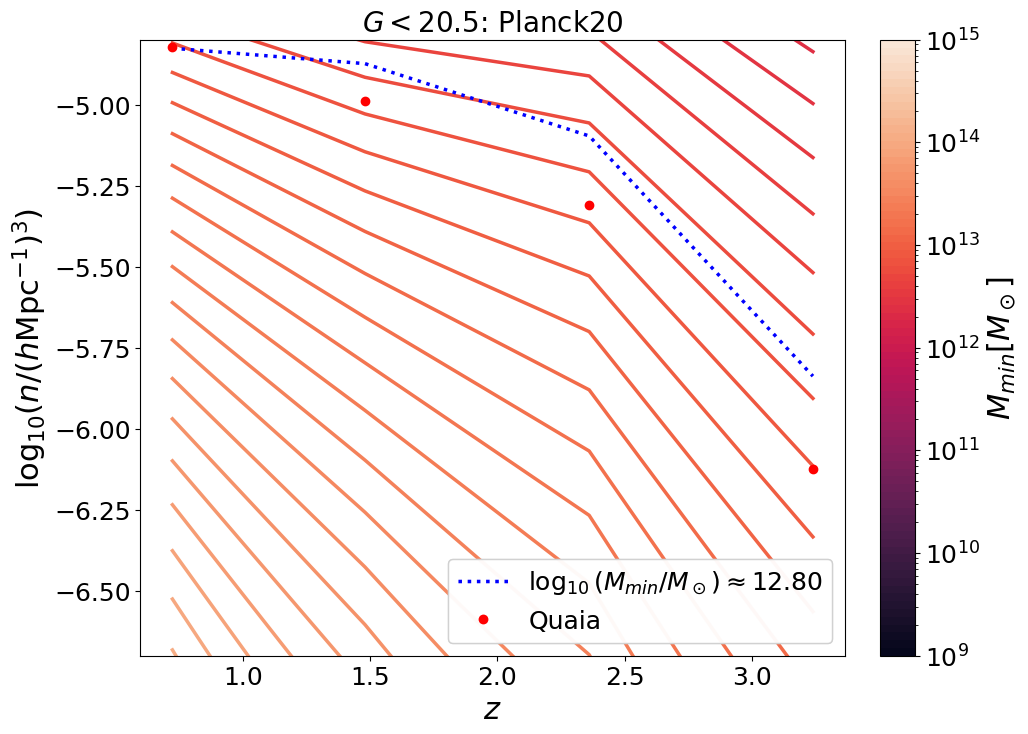

In [82]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap[k])
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

custom_lines = [Line2D([0], [0], color = 'blue', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
# plt.legend()
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(-6.7, -4.8)

# cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.BoundaryNorm(np.log10(bins), palette.N)), cax = fig.add_subplot(gs[:,-1]), label = '$\log_{10}(M_{min}/M_\odot)$')
cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

### Vary $f_{duty}$

In [83]:
fduty_array = np.logspace(-5,0, 51) #-4
n_m_array_3D = []
for i in z_array:

    n_m_array_3D.append([])
        
    for k in range(len(fduty_array)):

        n_m=np.ones(np.shape(bins))*fduty_array[k]
        n_m_array_3D[i].append(n_m)

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_3D[j][f[j]], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    plt.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(-6.7, -4.8)
ax1.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\o'
<>:26: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_38900/896671043.py:26: SyntaxWarning: invalid escape sequence '\o'
  cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/2313523635.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return 1/n_g*np.trapz(integrand*b, bins)
/tmp/ipykernel_38900/896671043.py:9: RuntimeWarning: divide by zero encountered in log10
  plt.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),


In [ ]:
cmap_fduty = sns.color_palette("mako", n_colors = len(fduty_array))
palette_fduty = matplotlib.colors.ListedColormap(cmap_fduty)
palette_fduty

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):
    
    n_q_theory = [M(bins_M_min_array[l], n_m_array_3D[j][k], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'blue', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(np.log10(bins[l]))) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
# plt.ylim(-6.7, -4.8)
ax1.set_ylim(-7.4, -3.1)
ax1.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.LogNorm(vmin=fduty_array[0], vmax = fduty_array[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$f_{duty}$')
plt.show()

# Perform $\chi^2$ fit
## $\chi_c^2=\sum \frac{\left(O_i-E_i\right)^2}{\sigma_i^2}$

In [ ]:
# Create the bins array
rmin = 10 # 0.1 # start higher # 1.4 # 30
rmax = 85 # 200
nbins = 20 #90 #20
rbins_chi2 = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
quaia.recenter(rbins_chi2)

In [ ]:
cf_chi2, cf_matter_chi2 = [], []
yerr_cf_chi2, b_cf_chi2 = [], []
b_cf_q_chi2 = []
i = 1
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = cosmo_planck18['Omega_m'], h = cosmo_planck18['h'], error = True)
    cf_chi2.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)

    # matter correlation function
    H0 = cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a)
    cf_matter_chi2.append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2.append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2.append(yerr)

    # qso bias
    b_cf_q_chi2.append(b_qso(cf, cf_matter, ccl.growth_rate(cosmo_planck18, a)))

In [ ]:
M_min_fit = []
for j in z_array:

    chi2 = []
    for m in bins:
        
#         n_m=np.zeros(np.shape(quaia.recenter(bins)))
#         n_m[quaia.recenter(bins)>=m]=fduty[j]
        n_m=np.ones(np.shape(bins))*fduty[j]
        bins_m = np.logspace(np.log10(m), M_max, 79)
        
        cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
        # cf_2h_zbin, b_q = cf_2h(bins, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j])
        chi2_m = (cf_chi2[j]-cf_2h_zbin)**2/cf_2h_zbin
        chi2_m[np.isnan(cf_2h_zbin)]=np.inf
        
        chi2.append(np.sum(chi2_m))

    k = np.argmin(chi2)
    print(chi2[k])
    M_min_fit.append(bins[k])

np.log10(M_min_fit)

In [ ]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            # n_m=np.zeros(np.shape(quaia.recenter(bins)))
            # n_m[quaia.recenter(bins)>=bins[l]]=fduty_array[k]
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), M_max, 79)
        
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
            # cf_2h_zbin, b_q = cf_2h(bins, n_m, a_zbin[labels[i]][j], cosmos[i], cf_matter_chi2[labels[i]][j])
            chi2_m = (cf_chi2[j]-cf_2h_zbin)**2/cf_2h_zbin
            # chi2_m[np.isnan(cf_2h_zbin)]=np.inf
            chi2_m[np.isnan(chi2_m)]=np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

### Enforce a hard limit on $n_q$

In [ ]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), M_max, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
            chi2_m = (cf_chi2[j]-cf_2h_zbin)**2/cf_2h_zbin
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

In [ ]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), M_max, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
            chi2_m = (cf_chi2[j]-cf_2h_zbin)**2
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

In [ ]:
M_min_fit, fduty_fit = [], []
for j in z_array:

    chi2 = np.zeros((len(bins), len(fduty_array)))

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            n_m=np.ones(np.shape(bins))*fduty_array[k]
            bins_m = np.logspace(np.log10(bins[l]), M_max, 79)
            
            cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
            chi2_m = (cf_chi2[j]-cf_2h_zbin)**2/yerr_cf_chi2[j]**2
            chi2_m[np.isnan(chi2_m)]=np.inf

            n_q_theory = M(bins_m, n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1]
            if np.abs(n_q_theory-n_q[j])/n_q[j]>=0.05:
                chi2_m = np.inf
            chi2[l,k]=np.sum(chi2_m)

    ind = np.unravel_index(np.argmin(chi2), chi2.shape)
    print(chi2[ind])
    M_min_fit.append(bins[ind[0]])
    fduty_fit.append(fduty_array[ind[-1]])

np.log10(M_min_fit), np.log10(fduty_fit)

In [ ]:
def f0(x, a, cf_matter, yerr_cf, cf, cosmo = cosmo_planck18): #quaia):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, b_q = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    
    return np.sum((cf-cf_2h_zbin)**2/yerr_cf**2)

### Add a number density constraint

In [ ]:
def constraint(x, a, n_q, cosmo = cosmo_planck18, error = 0.05):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]

    return error-np.abs(n_q_theory-n_q)/n_q

In [ ]:
i = 1
errors = [0.05, 0.05, 0.05, 0.05]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    sigma = np.load('../results/sigma_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}.npy'.format(G_hi, rmin, rmax, nbins, j))

    fun = lambda x: f0(x, a_zbin[j], cf_matter_chi2[j], sigma, cf_chi2[j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[j], n_q[j], error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [ ]:
# Create the bins array
rmin = 30 # 0.1 # start higher # 1.4 # 30
rmax = 80 # 200
nbins = 20 #90 #20
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
quaia.recenter(rbins_chi2)

In [ ]:
cf_chi2, cf_matter_chi2 = [], []
yerr_cf_chi2, b_cf_chi2 = [], []
b_cf_q_chi2 = []
i = 1
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = cosmo_planck18['Omega_m'], h = cosmo_planck18['h'], error = True)
    cf_chi2.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)

    # matter correlation function
    H0 = cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a)
    cf_matter_chi2.append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2.append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2.append(yerr)

    # qso bias
    b_cf_q_chi2.append(b_qso(cf, cf_matter, ccl.growth_rate(cosmo_planck18, a)))

### Use the sigma directly

In [ ]:
i = 1
errors = [0.05, 0.05, 0.05, 0.05]
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))))

    fun = lambda x: f0(x, a_zbin[j], cf_matter_chi2[j], sigma, cf_chi2[j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[j], n_q[j], error = errors[j])})
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

In [ ]:
for j in z_array:
    
    print('{}<z<={}'.format(j, j+1))
    x = fduty_fit[j], np.log10(M_min_fit[j])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    sigma = np.sqrt(np.diag(C))
    chi2 = f0(x, a_zbin[j], cf_matter_chi2[j], sigma, cf_chi2[j])
    df = nbins-len(x)
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j], error = errors[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2f}\n'.format(stats.chi2.sf(chi2, df)))

In [ ]:
chi2_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
cons_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
for j in z_array:

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
            
            x = fduty_array[k], np.log10(bins[l])

            C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
            sigma = np.sqrt(np.diag(C))
            
            chi2_m = f0(x, a_zbin[j], cf_matter_chi2[j], sigma, cf_chi2[j])
            chi2_grid[j][l,k]=chi2_m
            
            cons = constraint(x, a_zbin[j], n_q[j], error = errors[j])
            cons_grid[j][l,k]=cons

In [ ]:
cmap_chi2 = sns.cubehelix_palette(start=2, rot=0, dark=0, light=0.95, as_cmap=True)
cmap_chi2

In [ ]:
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, hspace = 0.15, wspace = 0.1)

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j*2])
    image = ax1.imshow(np.log10(chi2_grid[j]), cmap = cmap_chi2, vmin = 1.2180764233774466, vmax = 11.97918218567888, extent =  [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    ax1.set_ylabel('$\log_{10} (M_{min}/M_\odot)$')
    fig.colorbar(image, label='$\log_{10} (\chi^2)$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')
    
    ax1 = fig.add_subplot(gs[j*2+1])
    image = ax1.imshow(cons_grid[j], cmap = palette_fduty, norm = 'symlog', vmin = -4348491.828200184, vmax = 0.09959201649593023, extent = [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    fig.colorbar(image, label='$\Delta n_q$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')

plt.show()

## Sanity check

In [ ]:
def f0_GLS(x, a, cf_matter, C, cf, n_q, cosmo = cosmo_planck18, error = 0.05, constraint = True):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)

    if constraint == False:
        n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]
        penalty = (n_q_theory-n_q)**2/(error*n_q)
    else:
        penalty = 0
        
    return (cf-cf_2h_zbin).T @ np.linalg.inv(C) @ (cf-cf_2h_zbin)+penalty

In [ ]:
i = 1
error = 0.05
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    C*= np.identity(len(C))
        
    fun = lambda x: f0_GLS(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j], error = error)
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[j], n_q[j], error = error)}) 
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

In [ ]:
for j in z_array:
    
    print('{}<z<={}'.format(j, j+1))
    x = fduty_fit[j], np.log10(M_min_fit[j])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    C*= np.identity(len(C))
    chi2 = f0_GLS(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j])
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j], error = errors[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2e}\n'.format(stats.chi2.sf(chi2, df)))

In [ ]:
chi2_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
cons_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
for j in z_array:

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            x = fduty_array[k], np.log10(bins[l])

            C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
            C*= np.identity(len(C))
            chi2_m = f0_GLS(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j])
            chi2_grid[j][l,k]=chi2_m
            cons = constraint(x, a_zbin[j], n_q[j], error = error)
            cons_grid[j][l,k]=cons

In [ ]:
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, hspace = 0.15, wspace = 0.1)

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j*2])
    image = ax1.imshow(np.log10(chi2_grid[j]), cmap = cmap_chi2, vmin = np.log10(50.13706414974333), vmax = np.log10(3216118165719.2197), extent =  [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    ax1.set_ylabel('$\log_{10} (M_{min}/M_\odot)$')
    fig.colorbar(image, label='$\log_{10} (\chi^2)$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')
    
    ax1 = fig.add_subplot(gs[j*2+1])
    image = ax1.imshow(cons_grid[j], cmap = palette_fduty, norm = 'symlog', vmin = -4348491.828200184, vmax = 0.09959201649593023, extent = [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    # ax1.set_ylabel('$\log_{10} (M_{min})$')
    fig.colorbar(image, label='$\Delta n_q$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')

plt.show()

### Use this form of the loss function: $\chi_c^2={\Delta^TC^{-1}}\Delta$

In [ ]:
def f0_GLS_solve(x, a, cf_matter, C, cf, n_q, cosmo = cosmo_planck18):  #quaia):
    
    fduty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*fduty
        
    cf_2h_zbin, _ = cf_2h(bins_m, n_m, a, cosmo, cf_matter, recenter = False)
    delta = cf-cf_2h_zbin
        
    return delta.T @ np.linalg.solve(C, delta)

In [ ]:
i = 1
error = 0.05
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    C*= np.identity(len(C))

    fun = lambda x: f0_GLS_solve(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[j], n_q[j], error = error)}) 
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

In [ ]:
for j in z_array:
    
    print('{}<z<={}'.format(j, j+1))
    x = fduty_fit[j], np.log10(M_min_fit[j])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    C*= np.identity(len(C))
    chi2 = f0_GLS_solve(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j])
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j], error = errors[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2e}\n'.format(stats.chi2.sf(chi2, df)))

In [ ]:
chi2_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
cons_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
for j in z_array:

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
        
            x = fduty_array[k], np.log10(bins[l])

            C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
            C*= np.identity(len(C))
            chi2_m = f0_GLS_solve(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j])
            chi2_grid[j][l,k]=chi2_m
            cons = constraint(x, a_zbin[j], n_q[j], error = error)
            cons_grid[j][l,k]=cons

In [ ]:
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, hspace = 0.15, wspace = 0.1)

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j*2])
    image = ax1.imshow(np.log10(chi2_grid[j]), cmap = cmap_chi2, vmin = np.log10(50.13706414974333), vmax = np.log10(3216118165719.2197), extent =  [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    ax1.set_ylabel('$\log_{10} (M_{min}/M_\odot)$')
    fig.colorbar(image, label='$\log_{10} (\chi^2)$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')
    
    ax1 = fig.add_subplot(gs[j*2+1])
    image = ax1.imshow(cons_grid[j], cmap = palette_fduty, norm = 'symlog', vmin = -4348491.828200184, vmax = 0.09959201649593023, extent = [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    # ax1.set_ylabel('$\log_{10} (M_{min})$')
    fig.colorbar(image, label='$\Delta n_q$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')

plt.show()

## Use the full covariance matrix

In [ ]:
fduty_guess = [0.018, 0.022, 0.056, 0.071]
M_min_guess = [12.86, 12.74, 12.79, 14]

In [ ]:
i = 1
error = 0.05
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    
    fun = lambda x: f0_GLS(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j], error = error)
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[j], n_q[j], error = error)}) 
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

In [ ]:
for j in z_array:
    
    print('{}<z<={}'.format(j, j+1))
    x = fduty_fit[j], np.log10(M_min_fit[j])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    chi2 = f0_GLS(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j], error = error)
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j], error = errors[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2e}\n'.format(stats.chi2.sf(chi2, df)))

In [ ]:
chi2_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
cons_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
for j in z_array:

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
            
            x = fduty_array[k], np.log10(bins[l])

            C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))

            chi2_m = f0_GLS(x, a_zbin[j], cf_matter_chi2[j], C, cf_chi2[j], n_q[j], error = error)
            chi2_grid[j][l,k]=chi2_m
            cons = constraint(x, a_zbin[j], n_q[j], error = error)
            cons_grid[j][l,k]=cons

In [ ]:
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, hspace = 0.15, wspace = 0.1)

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j*2])
    image = ax1.imshow(np.log10(chi2_grid[j]), cmap = cmap_chi2, vmin = np.log10(50.13706414974333), vmax = np.log10(3216118165719.2197), extent =  [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    # print(image.get_clim())
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    ax1.set_ylabel('$\log_{10} (M_{min}/M_\odot)$')
    fig.colorbar(image, label='$\log_{10} (\chi^2)$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')
    
    ax1 = fig.add_subplot(gs[j*2+1])
    image = ax1.imshow(cons_grid[j], cmap = palette_fduty, norm = 'symlog', vmin = -4348491.828200184, vmax = 0.09959201649593023, extent = [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    # print(image.get_clim())
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    # ax1.set_ylabel('$\log_{10} (M_{min})$')
    fig.colorbar(image, label='$\Delta n_q$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')

plt.show()

## Include some bins we aren't analyzing

In [ ]:
# Create the bins array
delta = 1
offset = 2.5*delta

rmin = 30 # 0.1 # start higher # 1.4 # 30
rmax = 80 # 200
nbins = 20 #90 #20
rbins_chi2 = np.linspace(rmin-offset, rmax+offset, nbins + 2*delta + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
quaia.recenter(rbins_chi2), np.diff(quaia.recenter(rbins_chi2))

In [ ]:
cf_chi2, cf_matter_chi2 = [], []
yerr_cf_chi2, b_cf_chi2 = [], []
b_cf_q_chi2 = []
i = 1
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins_chi2, Om0 = cosmo_planck18['Omega_m'], h = cosmo_planck18['h'], error = True)
    cf_chi2.append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)

    # matter correlation function
    H0 = cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins_chi2)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmo_planck18, r=rbins_Mpc, a=a)
    cf_matter_chi2.append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf_chi2.append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf_chi2.append(yerr)

    # qso bias
    b_cf_q_chi2.append(b_qso(cf, cf_matter, ccl.growth_rate(cosmo_planck18, a)))

In [ ]:
rpmask = (quaia.recenter(rbins_chi2) >= 30) & (quaia.recenter(rbins_chi2) <= 80)

## Solve for $\chi^2=\Delta^T x$ where $Cx=\Delta$

In [ ]:
i = 1
error = 0.05
res, M_min_fit, fduty_fit = [], [], []
for j in z_array:
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    
    fun = lambda x: f0_GLS_solve(x, a_zbin[j], cf_matter_chi2[j][rpmask], C, cf_chi2[j][rpmask], n_q[j])
    cons = ({'type': 'ineq', 'fun': lambda x: constraint(x, a_zbin[j], n_q[j], error = error)}) 
    
    res.append(minimize(fun, [fduty[j], M_min_array[j]], bounds = ((0,1), (9, 15)), constraints = cons))
    M_min_fit.append(10**res[j].x[-1])
    fduty_fit.append(res[j].x[0])
    
np.log10(M_min_fit), np.log10(fduty_fit), res

In [ ]:
for j in z_array:
    
    print('{}<z<={}'.format(j, j+1))
    x = fduty_fit[j], np.log10(M_min_fit[j])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
    chi2 = f0_GLS_solve(x, a_zbin[j], cf_matter_chi2[j][rpmask], C, cf_chi2[j][rpmask], n_q[j])
    
    print('           chi^2: {:.2f}'.format(chi2))
    print('   reduced chi^2: {:.2f}'.format(chi2/df))
    print('         delta n: {:.2e}'.format(constraint(x, a_zbin[j], n_q[j], error = errors[j])))
    print('condition number: {:.2f}'.format(np.linalg.cond(C)))
    print('             PTE: {:.2e}\n'.format(stats.chi2.sf(chi2, df)))

In [ ]:
chi2_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
cons_grid = {j: np.zeros((len(bins), len(fduty_array))) for j in z_array}
for j in z_array:

    for k in range(len(fduty_array)):
        
        for l in range(len(bins)):
            
            x = fduty_array[k], np.log10(bins[l])

            C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))

            chi2_m = f0_GLS_solve(x, a_zbin[j], cf_matter_chi2[j][rpmask], C, cf_chi2[j][rpmask], n_q[j])
            chi2_grid[j][l,k]=chi2_m
            cons = constraint(x, a_zbin[j], n_q[j], error = error)
            cons_grid[j][l,k]=cons

In [ ]:
cmap_chi2 = sns.cubehelix_palette(start=2, rot=0, dark=0, light=1, as_cmap=True)
cmap_chi2

In [ ]:
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, hspace = 0.15, wspace = 0.1)

for j in z_array:
    
    ax1 = fig.add_subplot(gs[j*2])
    image = ax1.imshow(np.log10(chi2_grid[j]), cmap = cmap_chi2, vmin = np.log10(50.13706414974333), vmax = np.log10(3216118165719.2197), extent =  [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    ax1.set_ylabel('$\log_{10} (M_{min}/M_\odot)$')
    fig.colorbar(image, label='$\log_{10} (\chi^2)$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')
    
    ax1 = fig.add_subplot(gs[j*2+1])
    image = ax1.imshow(cons_grid[j], cmap = palette_fduty, norm = 'symlog', vmin = -4348491.828200184, vmax = 0.09959201649593023, extent = [np.log10(fduty_array[0]), np.log10(fduty_array[-1]), np.log10(bins[0]), np.log10(bins[-1])], aspect = 'auto', origin = 'lower')
    # print(image.get_clim())
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(j, j+1))
    if j == 3:
        ax1.set_xlabel('$\log_{10} (f_{duty})$')
    # ax1.set_ylabel('$\log_{10} (M_{min})$')
    fig.colorbar(image, label='$\Delta n_q$')
    ax1.axhline(np.log10(M_min_fit[j]), color = 'red', linestyle = '--')
    ax1.axvline(np.log10(fduty_fit[j]), color = 'red', linestyle = '--')

plt.show()

## Plot results

In [ ]:
plt.plot(zbin, np.log10(M_min_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2025 (this work)')
plt.plot(zbin, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

In [ ]:
plt.plot(zbin, np.log10(fduty_fit), color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2025 (this work)')
plt.fill_between(zbin, np.log10(np.array(fduty)+fduty_err_hi), np.log10(np.array(fduty)-fduty_err_lo), alpha = 0.5, color = 'lightgreen')
plt.plot(zbin, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.show()

## Pick cosmology

In [ ]:
cosmo = 'Planck'

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin-2.5, rmax+2.5, nbins+2, j, cosmo))
            
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins_chi2), b_eff_cf20[j]**2*cf_matter_chi2[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = rmin, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = rmax, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # old fit
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5, 
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]),
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]),M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty_fit[j]), 
                                                                                                        np.log10(M_min_fit[j])), 
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')

    ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = rmin, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = rmax, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)
    
    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 3)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25_{}.npy'.format(G_hi, rmin-2.5, rmax+2.5, nbins+2, j, cosmo))
            
    ax1.errorbar(quaia.recenter(rbins_chi2), cf_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = rmin, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = rmax, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)
    # ax1.plot(quaia.recenter(rbins_chi2), b_eff_cf20[j]**2*cf_matter_chi2[j], linewidth = 2.5,
    #          label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')

    # old fit
    # cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_chi2[j], recenter = False)
    # ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5, 
    #          label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]),
    #          color = 'lightgreen')
    # ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]),M_max,79), n_m, a_zbin[j], cosmo_planck18, cf_matter_chi2[j], 
                            recenter = False)
    ax1.plot(quaia.recenter(rbins_chi2), cf_2h_zbin, linewidth = 2.5,
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty_fit[j]), 
                                                                                                        np.log10(M_min_fit[j])), 
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')
    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins_chi2)[0], x2 = rmin, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax2.fill_betweenx(np.linspace(3e-4, 5e1), x1 = rmax, x2 = quaia.recenter(rbins_chi2)[-1], color = 'grey', 
                      alpha = 0.5)

    # ax2.errorbar(quaia.recenter(rbins_chi2), b_cf_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
    #              color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    # ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 3e-1)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax2.set_ylim(0, 4)
    # ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))
            
    ax1.errorbar(quaia.recenter(rbins_chi2)[rpmask], cf_chi2[j][rpmask], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    scales = (quaia.recenter(rbins)<=rmin) | (quaia.recenter(rbins)>=rmax)
    ax1.errorbar(quaia.recenter(rbins)[scales], cf_zbin_percentile[j][scales], linewidth = 2.5, marker = 'o', color = 'red', 
                 markerfacecolor = 'white', yerr = yerr_cf[j][scales], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins)[0], x2 = rmin, color = 'grey', alpha = 0.5)
    ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = rmax, x2 = quaia.recenter(rbins)[-1], color = 'grey', alpha = 0.5)

    # old fit, all scales
    cf_2h_zbin, b_q = cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, color = 'lightgreen',
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]))
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*fduty[j]
    cf_2h_zbin, b_q = cf_2h(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a_zbin[j], cosmo_planck18, 
                            cf_matter_zbin_percentile[j], recenter = False)
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, 
             label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty_fit[j]), 
                                                                                                        np.log10(M_min_fit[j])),
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')

    ax2.errorbar(quaia.recenter(rbins), b_cf[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_cf20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(0, 10), x1 = quaia.recenter(rbins)[0], x2 = rmin, color = 'grey', alpha = 0.5)
    ax2.fill_betweenx(np.linspace(0, 10), x1 = rmax, x2 = quaia.recenter(rbins)[-1], color = 'grey', alpha = 0.5)

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    ax1.set_xscale('log')
    ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
            
    if j % 2 != 0:
        k+=4

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    b_q = [cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], 
                 recenter = False)[1] for j in z_array]
    zbin = 1/np.array(a_zbin)-1
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap[k]) #grey,
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[j], cosmo_planck18, 
             cf_matter_zbin_percentile[j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(0, zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), 
                                          '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[j], cosmo_planck18, 
             cf_matter_zbin_percentile[j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(0, zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), 
                                          '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

plt.show()

In [ ]:
for k in range(len(bins)):
    M_vary = np.log10(M_min_fit[j])-1+k/int(len(bins)/2)
    if M_vary == np.log10(M_min_fit[j]):
        print(M_vary,'*')
    else:
        print(M_vary)

In [ ]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

zbin = 1/np.array(a_zbin)-1
# for k in range(len(bins)):
    
#     b_q = [cf_2h(bins_M_min_array[k], n_m_array_2D[j][k], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j], 
#                  recenter = False)[1] for j in z_array]
#     # zbin = 1/np.array(a_zbin[labels[i]])-1
#     ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap[k]) #grey,
    
b_q = [cf_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], 
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [cf_2h(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[j], cosmo_planck18, 
             cf_matter_zbin_percentile[j], recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [cf_2h(np.logspace(np.log10(M_min_fit[j])-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[j], 
                 cosmo_planck18, cf_matter_zbin_percentile[j], recenter = False)[1] for j in z_array]
    # b_q=[]
    # for j in z_array:
    #     M_mins = np.log10(np.logspace(np.log10(M_min_fit[j])-1, np.log10(M_min_fit[j])+1, 79))
    #     b_q.append(cf_2h(np.logspace(M_mins[k], 16.8, 79), np.ones(np.shape(bins))*fduty[j], a_zbin[labels[i]][j], 
    #                  cosmos[i], cf_matter_zbin_percentile[labels[i]][j], recenter = False)[1])
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), 
                                          '$\chi^2$ minimization', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1

for k in range(len(bins)):
    
    M_h = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap[k]) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), np.ones(np.shape(bins))*fduty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/cosmo_planck18['h'])]*len(z), [np.log10(3e12/cosmo_planck18['h'])]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo_planck18['h'])]*len(z), [np.log10(4e12/cosmo_planck18['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo_planck18['h'])]*len(z), [np.log10(10**12.62/cosmo_planck18['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min), '$\chi^2$ minimization',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
ylim = -6.5, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(bins_M_min_array[k], n_m_array_2D[j][k], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap[k])

n_q_theory, n_q_theory_fit = [], []
for j in z_array:
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*fduty_fit[j]
    # n_m[quaia.recenter(bins)>=M_min_fit[j]]=fduty_fit[j]
    n_q_theory_fit.append(M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = '$\chi^2$ minimization'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
# plt.legend()
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette, norm = matplotlib.colors.LogNorm(vmin=bins[0], vmax = bins[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$M_{min}[M_\odot]$')
plt.show()

fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m=np.ones(np.shape(bins))*fduty_array[k]
        # n_m[quaia.recenter(bins)>=M_min_fit[j]]=fduty_array[k]
        n_q_theory.append(M(np.logspace(np.log10(M_min_fit[j]), M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(M_min)) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.legend()

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_fduty, norm = matplotlib.colors.LogNorm(vmin=fduty_array[0], vmax = fduty_array[-1])), cax = fig.add_subplot(gs[:,-1]), label = '$f_{duty}$')
plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 10))
gs = gridspec.GridSpec(1, 1, height_ratios = [1], hspace = 0, wspace = 0)

k = 0
j = 1

ax1 = fig.add_subplot(gs[0])
        
sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N25.npy'.format(G_hi, rmin, rmax, nbins, j))))
ax1.errorbar(quaia.recenter(rbins_chi2)[rpmask], cf_chi2[j][rpmask], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
            yerr = sigma, markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
scales = (quaia.recenter(rbins)<=rmin) | (quaia.recenter(rbins)>=rmax)
ax1.errorbar(quaia.recenter(rbins)[scales], cf_zbin_percentile[j][scales], linewidth = 2.5, marker = 'o', color = 'red', markerfacecolor = 'white',
            yerr = yerr_cf[j][scales], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = quaia.recenter(rbins)[0], x2 = rmin, color = 'grey', alpha = 0.5, label = 'scales excluded from fit')
ax1.fill_betweenx(np.linspace(3e-4, 5e1), x1 = rmax, x2 = quaia.recenter(rbins)[-1], color = 'grey', alpha = 0.5)

# plot new fit
n_m=np.zeros(np.shape(bins))
n_m[bins>=M_min_fit[j]]=fduty[j]
cf_2h_zbin, b_q = cf_2h(bins, n_m, a_zbin[j], cosmo_planck18, cf_matter_zbin_percentile[j], recenter = False)
ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, 
         label = r'$\xi_{{q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty_fit[j]),np.log10(M_min_fit[j])), 
         color = 'darkblue')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
# ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)
ax1.legend(title = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), title_fontsize = 18)

ax1.set_ylabel(r'$\xi(s)$')

# if scale == 'log':
ax1.set_xscale('log')

ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected

plt.show()